# 1. Predicting Student Performance — Regression Track

**23CSE301 Machine Learning Capstone · Review 1**
**Project:** *Predictive Analytics Across Domains: Student Performance, Sentiment Classification and Customer Segmentation*
**Track owner:** _(student name)_

> ⚠️ **Synthetic data.** The dataset author states that this data "is synthetic and created for
> illustrative purposes" and that its relationships "may not reflect real-world scenarios".
> Every result in this notebook describes this synthetic data, not real students.

**Review 1 scope:** the complete regression track (ten algorithms). Classification Part A is in
`classification.ipynb`; Classification Part B and clustering belong to Review 2 and are not in this
repository.

**Reading guide.** Each section starts with a Markdown cell that says *what* is done, *why*, and the
*ML concept* involved, followed by the code and its output. Reusable helpers live in `src/`; where a
notebook step calls one, its source code is printed with `show_source(...)` so it can be read here.
Cells marked **✍️ TEAM ANALYSIS REQUIRED** are for the team's own observations.

| # | Section | # | Section |
|---|---|---|---|
| 1 | Project title | 11 | Target distribution |
| 2 | Problem statement | 12 | Feature distributions |
| 3 | Dataset source and provenance | 13 | Outlier analysis |
| 4 | Dataset loading | 14 | Correlation heatmap |
| 5 | Shape and schema | 15 | Feature–target relationships |
| 6 | First and representative rows | 16 | Leakage and identifier analysis |
| 7 | Data types | 17 | Train/test split |
| 8 | Missing-value audit | 18 | Preprocessing strategy |
| 9 | Duplicate audit | 19 | Feature engineering |
| 10 | Descriptive statistics | 20 | The ten regression algorithms and comparison table |
| | | 21 | Cross-validation, tuning, diagnostics and saved models |
| | | 22 | Model selection and conclusions *(team)* |

## 2. Problem statement

**Goal:** predict a student's **`Performance Index`** from five attributes describing study habits,
prior results and lifestyle.

| Item | Definition |
|---|---|
| Target (*y*) | `Performance Index` — a score from 10 to 100 (the author states it is rounded to the nearest integer). |
| Inputs (*X*) | `Hours Studied`, `Previous Scores`, `Extracurricular Activities`, `Sleep Hours`, `Sample Question Papers Practiced`. |
| Task type | **Supervised regression**: the target is a continuous numeric quantity and every row has a known target. |
| Evaluation (course guideline 3.1) | R², RMSE and MAE on one held-out test set; 5-fold cross-validated R² for the two best models. |
| Required algorithms | Ten regressors (section 20), all trained on the same preprocessed training data and scored on the same test set. |

**Concept — why regression, not classification:** the quantity to predict is a number on an ordered
scale where the *size* of an error matters (predicting 70 for a true 72 is better than predicting 40).
Regression models and metrics measure exactly that distance.

## 3. Dataset source and provenance

**What:** record where the data comes from and prove that the file we use is the file we documented.

**Why:** results are only reproducible if everyone uses byte-identical data. The SHA-256 checksum is a
fingerprint of the file: if a single byte changes, the checksum changes and loading stops with an error.

| Field | Value |
|---|---|
| Name | *Student Performance (Multiple Linear Regression)* |
| Kaggle page | https://www.kaggle.com/datasets/nikhil7280/student-performance-multiple-linear-regression |
| Author (owner) | Nikhil Narayan |
| Licence (as stated in the dataset description) | "Anyone is free to share and use the data" |
| Synthetic | Yes — stated by the author |
| Raw data in the repository? | No — kept local and checksum-verified (`docs/dataset_sources.md`) |

The next cell measures the file's checksum, size and shape now. First the environment is set up.

In [1]:
# --- Environment set-up --------------------------------------------------------
import sys
import platform
from pathlib import Path

# Find the project root (the folder containing src/config.py). This works whether
# the notebook is opened from notebooks/ or from the project root, and avoids any
# hard-coded absolute path.
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src" / "config.py").exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

from src import config, show_source
from src.plotting import set_style

set_style()                                   # titles, labels, colourblind palette
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)

# Only folder NAMES are printed, so no personal absolute paths end up in the committed notebook.
print(f"Python        {platform.python_version()}  (environment: {Path(sys.prefix).name})")
print(f"numpy {np.__version__} | pandas {pd.__version__} | scikit-learn {sklearn.__version__} "
      f"| matplotlib {matplotlib.__version__} | seaborn {sns.__version__}")
print(f"Project root  .../{ROOT.name}")
print(f"Random seed   {config.RANDOM_STATE}   test size {config.TEST_SIZE}   CV folds {config.CV_FOLDS}")
print(f"Run mode      {config.RUN_MODE}" + ("   (DEV RUN - outputs carry the '_dev' suffix, NOT reported results)"
                                             if config.RUN_MODE == "dev" else ""))

Python        3.13.2  (environment: ml-capstone)
numpy 2.5.3 | pandas 3.0.6 | scikit-learn 1.9.1 | matplotlib 3.11.2 | seaborn 0.13.2
Project root  .../Machine Learning project
Random seed   42   test size 0.2   CV folds 5
Run mode      full


**Measured provenance.** The checksum, size and shape of the file on disk, measured now and compared with the contract.

In [2]:
from src.data_loading import provenance_record

prov = provenance_record(config.STUDENT)
pd.Series(prov, name="value").to_frame()

,value
dataset,student_performance
file,Student_Performance.csv
source_url,https://www.kaggle.com/datasets/nikhil7280/stu...
bytes,175071
sha256,93793b00d9026d0b4907df0ca9f88b3696747c7496679d...
sha256_matches_contract,True
rows,10000
columns,6
recorded_at_utc,2026-09-24T10:23:05+00:00


## 4. Dataset loading

**What:** read `data/raw/Student_Performance.csv` with `load_raw`, which checks the file against the
dataset contract in `src/config.py` (checksum, row count, exact column names and order).

**Why:** a silent schema change (a renamed column, a truncated download) would otherwise surface much
later as a confusing modelling error or, worse, as plausible but wrong results. Loading does **no**
cleaning or transformation — it only reads and verifies. The raw file itself is read-only and is never
modified by this notebook.

In [3]:
from src.data_loading import load_raw

show_source(load_raw)

def load_raw(contract: DatasetContract, verify_checksum: bool = True) -> pd.DataFrame:
    """Read a raw CSV and verify it against its contract.

    Checks, in order: file exists, SHA-256 matches, row count matches,
    column names and order match. Any failure raises ``ContractError``.
    """
    path = contract.path
    if not path.exists():
        raise FileNotFoundError(
            f"{path} is missing. Run `python scripts/setup_data.py --source <folder>` "
            "(see docs/dataset_sources.md for where to obtain the file)."
        )
    if verify_checksum:
        actual = sha256_file(path)
        if actual != contract.sha256:
            raise ContractError(
                f"Checksum mismatch for {path.name}: got {actual}, expected {contract.sha256}"
            )
    df = pd.read_csv(path)
    problems = []
    if len(df) != contract.n_rows:
        problems.append(f"rows: got {len(df)}, expected {contract.n_rows}")
    if tuple(df.columns) != contract.columns:
      

**Load and verify.** Read the CSV through `load_raw`; any mismatch with the contract stops the notebook here instead of producing wrong results later.

In [4]:
contract = config.STUDENT
raw = load_raw(contract)          # raises ContractError if the file differs from the contract
print(f"Loaded {contract.filename}: {raw.shape[0]:,} rows x {raw.shape[1]} columns")

Loaded Student_Performance.csv: 10,000 rows x 6 columns


## 5. Shape and schema

**What:** confirm the dimensions and give every column a **role**: numeric feature, categorical feature,
target, or excluded.

**Why:** the role decides how a column is preprocessed later (scaled, one-hot encoded, predicted, or
dropped). Roles come from the contract in `src/config.py`, so the notebook, the tests and the
validation script all use the same definition.

In [5]:
def column_role(col):
    if col == contract.target:
        return "target"
    if col in contract.numeric_features:
        return "numeric feature"
    if col in contract.categorical_features:
        return "categorical feature"
    if col in contract.excluded:
        return "excluded"
    return "UNASSIGNED"

schema = pd.DataFrame({
    "role": [column_role(c) for c in raw.columns],
    "dtype": raw.dtypes.astype(str).values,
    "n_unique": raw.nunique().values,
}, index=pd.Index(raw.columns, name="column"))

print(f"Shape: {raw.shape}  (rows, columns)")
assert "UNASSIGNED" not in schema["role"].values, "every column must have a role"
schema

Shape: (10000, 6)  (rows, columns)


,role,dtype,n_unique
column,,,
Hours Studied,numeric feature,int64,9
Previous Scores,numeric feature,int64,60
Extracurricular Activities,categorical feature,str,2
Sleep Hours,numeric feature,int64,6
Sample Question Papers Practiced,numeric feature,int64,10
Performance Index,target,float64,91


## 6. First and representative rows

**What:** show the first five rows and a random sample of five rows (seeded, so it is reproducible).

**Why:** the first rows of a file are not necessarily typical — files are often sorted or grouped. A
random sample gives a fairer impression of what a row looks like.

In [6]:
display(raw.head())
display(raw.sample(5, random_state=config.RANDOM_STATE))

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
6252,5,69,No,8,2,51.0
4684,2,46,Yes,4,8,20.0
1731,7,56,Yes,7,5,46.0
4742,6,42,Yes,8,5,28.0
4521,7,53,No,4,6,41.0


## 7. Data types

**What:** check each column's storage type and whether numeric columns hold only whole numbers.

**Why:** the type decides the preprocessing. Numbers can be scaled; text categories must be encoded.
A numeric column stored as text (for example because of a stray `"N/A"`) would be a data-quality
problem.

**Note on pandas 3:** pandas ≥ 3.0 stores text columns with the dtype `str` instead of `object`. Code
that selects text columns with `select_dtypes("object")` silently misses them, which is why this
project takes column lists from the contract instead of guessing them from dtypes.

In [7]:
num_cols = list(contract.numeric_features) + [contract.target]
dtype_table = pd.DataFrame({
    "dtype": raw.dtypes.astype(str),
    "min": raw[num_cols].min(),
    "max": raw[num_cols].max(),
    "whole numbers only": {c: bool((raw[c] == raw[c].round()).all()) for c in num_cols},
})
dtype_table = dtype_table.reindex(raw.columns)          # keep the file's column order
dtype_table.index.name = "column"
display(dtype_table)

cat = contract.categorical_features[0]
print(f"'{cat}' values and counts:")
print(raw[cat].value_counts(dropna=False).to_string())

,dtype,min,max,whole numbers only
column,,,,
Hours Studied,int64,1.0,9.0,True
Previous Scores,int64,40.0,99.0,True
Extracurricular Activities,str,NaN,NaN,NaN
Sleep Hours,int64,4.0,9.0,True
Sample Question Papers Practiced,int64,0.0,9.0,True
Performance Index,float64,10.0,100.0,True


'Extracurricular Activities' values and counts:
Extracurricular Activities
No     5052
Yes    4948


## 8. Missing-value audit  *(rubric A1, B1)*

**What:** count missing values in every column, and check the categorical column for disguised
missing values (empty strings, "NA", "?", "unknown").

**Why:** most scikit-learn estimators fail on missing values, and disguised placeholders are easy to
miss because pandas does not count them as missing.

**Strategy (applies whatever the counts are):** imputation is part of the preprocessing *pipeline* —
median for numeric columns, most-frequent category for categorical columns. Because it is inside the
pipeline, the imputation values are learned from the training data only. If the data has no missing
values the imputers change nothing, but they keep the pipeline safe for new inputs.

In [8]:
from src.data_loading import audit_columns

audit = audit_columns(raw)
display(audit)
print(f"Total missing cells: {int(raw.isna().sum().sum())}")

placeholders = {"", "na", "n/a", "nan", "none", "null", "?", "unknown", "error"}
disguised = raw[cat].astype(str).str.strip().str.lower().isin(placeholders).sum()
print(f"Disguised missing values in '{cat}': {int(disguised)}")

,dtype,n_missing,pct_missing,n_unique,example
column,,,,,
Hours Studied,int64,0,0.0,9,7
Previous Scores,int64,0,0.0,60,99
Extracurricular Activities,str,0,0.0,2,Yes
Sleep Hours,int64,0,0.0,6,9
Sample Question Papers Practiced,int64,0,0.0,10,1
Performance Index,float64,0,0.0,91,91.0


Total missing cells: 0
Disguised missing values in 'Extracurricular Activities': 0


## 9. Duplicate audit  *(rubric B1)*

**What:** count duplicates under two definitions, then remove only the **exact** duplicates.

| Definition | Meaning |
|---|---|
| Exact duplicate | every column, including the target, equals an earlier row |
| Feature-only duplicate | the five inputs equal an earlier row (the target may differ) |

**Why the distinction matters:** an exact duplicate adds no new information and, if one copy lands in
the training set and the other in the test set, the model is partly tested on a row it has already
seen. A feature-only duplicate with a *different* target is a different observation — two students
with identical habits but different results — and removing it would discard real variation.

**Why before the split:** dropping exact duplicate rows is deterministic (it uses no statistics), so it
cannot leak information, and doing it first prevents copies straddling train and test.

In [9]:
from src.data_loading import duplicate_report

features = list(contract.numeric_features + contract.categorical_features)
dup_table = duplicate_report(raw, {"exact (all columns)": None, "feature-only": features})
display(dup_table)

# Feature combinations that occur more than once, and how many of them have different targets
grp = raw.groupby(features)[contract.target].agg(["size", "nunique"])
repeated = grp[grp["size"] > 1]
print(f"Feature combinations occurring more than once: {len(repeated):,}")
print(f"  ... of which appear with different target values: {int((repeated['nunique'] > 1).sum()):,}")
print(f"Distinct feature combinations observed: {len(grp):,}")

,columns,n_duplicates
key,,
exact (all columns),all columns,127
feature-only,"Hours Studied, Previous Scores, Sleep Hours, S...",792


Feature combinations occurring more than once: 755
  ... of which appear with different target values: 647
Distinct feature combinations observed: 9,208


**Removing the exact duplicates.** The helper's source is printed first; it keeps the first copy of each exact duplicate row and reports the counts before and after.

In [10]:
from src.preprocessing import drop_exact_duplicates

show_source(drop_exact_duplicates)
df, dedup_report = drop_exact_duplicates(raw)          # subset=None -> exact duplicates only
pd.Series(dedup_report, name="exact-duplicate removal").to_frame()

def drop_exact_duplicates(
    df: pd.DataFrame, subset: list[str] | None = None
) -> tuple[pd.DataFrame, dict]:
    """Drop rows that repeat an earlier row (first occurrence is kept).

    ``subset=None`` means every column must match. Returns the de-duplicated
    frame and a before/after report so the decision is visible.
    """
    before = len(df)
    mask = df.duplicated(subset=subset, keep="first")
    out = df.loc[~mask].copy()
    report = {
        "key": "all columns" if subset is None else ", ".join(subset),
        "rows_before": before,
        "duplicates_removed": int(mask.sum()),
        "rows_after": len(out),
        "duplicates_remaining_under_key": int(out.duplicated(subset=subset).sum()),
    }
    return out, report



,exact-duplicate removal
key,all columns
rows_before,10000
duplicates_removed,127
rows_after,9873
duplicates_remaining_under_key,0


From here on, `df` (the de-duplicated frame) is the working dataset. The raw file on disk is unchanged.

> ### ✍️ TEAM ANALYSIS REQUIRED — `REG-B1-DUPLICATES`: Missing values and duplicates
> **Author:** _(write your name)_
>
> Write this in your own words, based on the output above. Course guideline 7.5 does not allow
> generative-AI tools to write analysis or interpretation.
>
> - What did the missing-value audit show, and why is keeping the imputers in the pipeline still reasonable (or not)?
> - Why is removing exact duplicates but keeping feature-only duplicates defensible for this dataset? Use the counts above.
> - Could the remaining feature-only duplicates affect how the test score should be read? (See also the overlap check in section 17.)
>
> *When done, replace this whole cell with your answer under the heading `### Team analysis — REG-B1-DUPLICATES`.*

## 10. Descriptive statistics

**What:** count, mean, standard deviation, quartiles, skewness and kurtosis of every numeric column, on
the de-duplicated data.

**Concepts:**
* **Skewness** measures asymmetry: 0 = symmetric, positive = long right tail, negative = long left tail.
* **Excess kurtosis** compares tail weight with a normal distribution: 0 = normal-like, negative =
  flatter with lighter tails (a uniform distribution has −1.2), positive = heavier tails.

In [11]:
desc = df[num_cols].describe().T
desc["skew"] = df[num_cols].skew()
desc["excess kurtosis"] = df[num_cols].kurt()
desc["n_unique"] = df[num_cols].nunique()
desc = desc.round(3)
display(desc)

from src.evaluation import save_table
save_table(desc, "regression_descriptive_statistics", floatfmt=".3f")

print(f"'{cat}' share of rows:")
print(df[cat].value_counts(normalize=True).round(4).to_string())

,count,mean,std,min,25%,50%,75%,max,skew,excess kurtosis,n_unique
column,,,,,,,,,,,
Hours Studied,9873.0,4.992,2.589,1.0,3.0,5.0,7.0,9.0,-0.003,-1.234,9
Previous Scores,9873.0,69.441,17.326,40.0,54.0,69.0,85.0,99.0,0.006,-1.212,60
Sleep Hours,9873.0,6.532,1.698,4.0,5.0,7.0,8.0,9.0,-0.041,-1.259,6
Sample Question Papers Practiced,9873.0,4.583,2.867,0.0,2.0,5.0,7.0,9.0,-0.035,-1.214,10
Performance Index,9873.0,55.217,19.209,10.0,40.0,55.0,70.0,100.0,-0.000,-0.860,91


'Extracurricular Activities' share of rows:


Extracurricular Activities
No     0.505
Yes    0.495


## 11. Target distribution  *(rubric A1, A2)*

**What:** a histogram with a density curve, the mean and median, and a box plot of `Performance Index`.

**Why:** the shape of the target affects modelling. A strongly skewed target may call for a
transformation; values piled up at the ends of the range can indicate clipping (for example, scores
capped at 10 or 100), which a model cannot predict beyond.

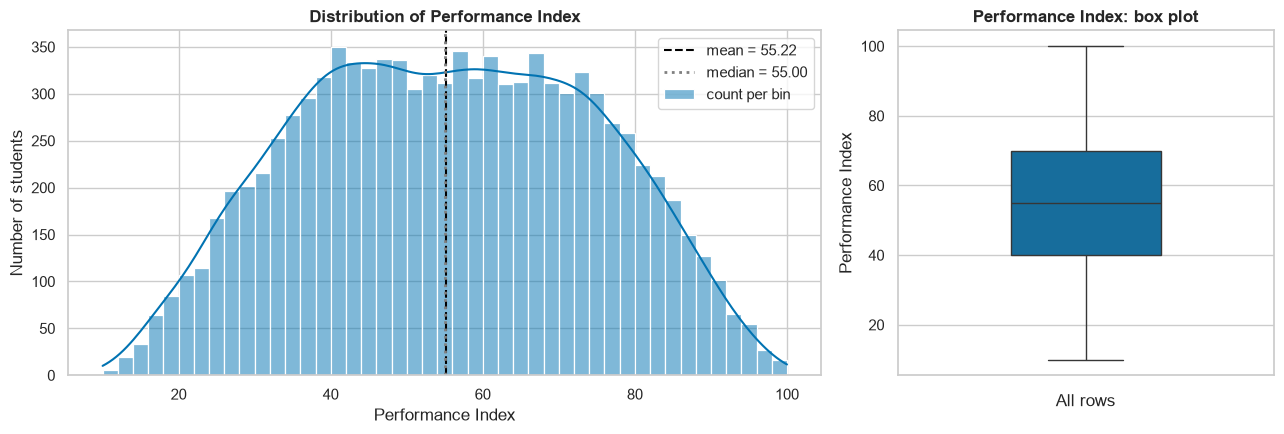

skew = -0.0004   excess kurtosis = -0.8601
rows at the minimum (10): 1   rows at the maximum (100): 3


In [12]:
from src.plotting import finalize

target = contract.target
y_all = df[target]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), gridspec_kw={"width_ratios": [2, 1]})
sns.histplot(y_all, bins=45, kde=True, ax=axes[0], label="count per bin")
axes[0].axvline(y_all.mean(), color="black", linestyle="--", label=f"mean = {y_all.mean():.2f}")
axes[0].axvline(y_all.median(), color="grey", linestyle=":", linewidth=2, label=f"median = {y_all.median():.2f}")
axes[0].set_title("Distribution of Performance Index")
axes[0].set_xlabel("Performance Index")
axes[0].set_ylabel("Number of students")
axes[0].legend()

sns.boxplot(y=y_all, ax=axes[1], width=0.4)
axes[1].set_title("Performance Index: box plot")
axes[1].set_xlabel("All rows")
axes[1].set_ylabel("Performance Index")
finalize(fig, "regression_target_distribution")
plt.show()

print(f"skew = {y_all.skew():.4f}   excess kurtosis = {y_all.kurt():.4f}")
print(f"rows at the minimum ({y_all.min():.0f}): {(y_all == y_all.min()).sum()}   "
      f"rows at the maximum ({y_all.max():.0f}): {(y_all == y_all.max()).sum()}")

### Technical Result
*Generated from the computation above; it updates automatically when the notebook is re-run.*

In [13]:
from IPython.display import Markdown     # renders the generated facts as a bullet list

display(Markdown("\n".join([
    f"- n = {len(y_all):,} rows (de-duplicated data); range {y_all.min():.0f}–{y_all.max():.0f}.",
    f"- Mean = {y_all.mean():.3f}, median = {y_all.median():.3f}, standard deviation = {y_all.std():.3f}.",
    f"- Skewness = {y_all.skew():.4f}; excess kurtosis = {y_all.kurt():.4f}.",
    f"- Rows at the minimum value: {(y_all == y_all.min()).sum()}; at the maximum value: {(y_all == y_all.max()).sum()}.",
])))

- n = 9,873 rows (de-duplicated data); range 10–100.
- Mean = 55.217, median = 55.000, standard deviation = 19.209.
- Skewness = -0.0004; excess kurtosis = -0.8601.
- Rows at the minimum value: 1; at the maximum value: 3.

> ### ✍️ TEAM ANALYSIS REQUIRED — `REG-A3-TARGET`: Target distribution
> **Author:** _(write your name)_
>
> Write this in your own words, based on the output above. Course guideline 7.5 does not allow
> generative-AI tools to write analysis or interpretation.
>
> - What shape does the Performance Index distribution have? Is it skewed, and how do the skew and kurtosis values support your answer?
> - Do the counts at the minimum and maximum suggest the scores were capped? Would that matter for any model?
> - Does the target need a transformation before modelling? Why or why not?
>
> *When done, replace this whole cell with your answer under the heading `### Team analysis — REG-A3-TARGET`.*

## 12. Feature distributions  *(rubric A2)*

**What:** one distribution plot per input feature.

**Why:** the rubric requires a distribution plot for each feature. All four numeric features are
**discrete** (whole numbers with few distinct values), so bar charts of the count of each value are
more honest than smoothed histograms, which would suggest values that never occur.

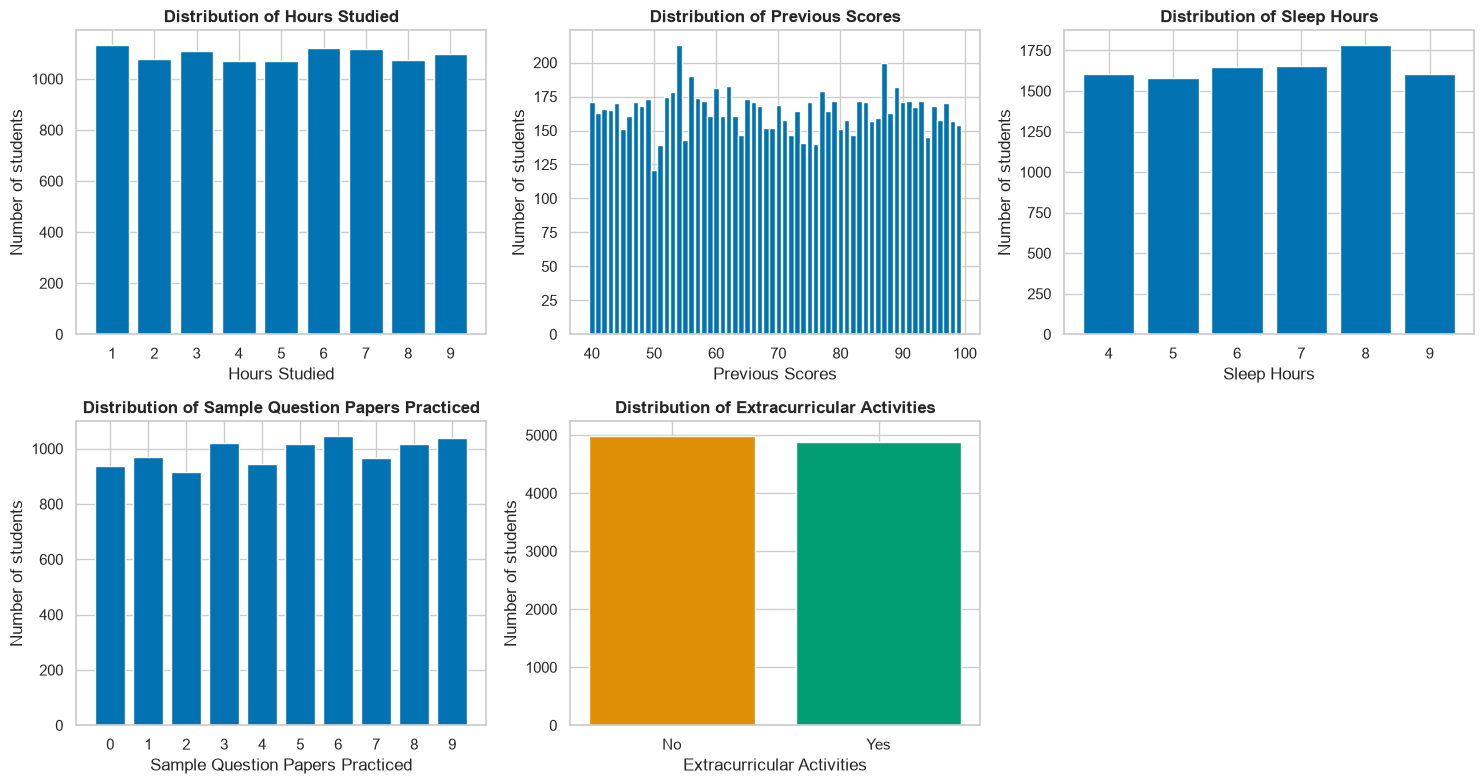

,distinct values,min,max,least common value count,most common value count
column,,,,,
Hours Studied,9,1,9,1069,1133
Previous Scores,60,40,99,121,213
Sleep Hours,6,4,9,1580,1784
Sample Question Papers Practiced,10,0,9,917,1046


In [14]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, contract.numeric_features):
    counts = df[col].value_counts().sort_index()
    ax.bar(counts.index, counts.values, width=0.8 if counts.index.nunique() < 20 else 0.9)
    if len(counts) <= 10:
        ax.set_xticks(counts.index)                    # one tick per possible value
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Number of students")

ax = axes.flat[4]
counts = df[cat].value_counts()
ax.bar(counts.index, counts.values, color=sns.color_palette("colorblind")[1:3])
ax.set_title(f"Distribution of {cat}")
ax.set_xlabel(cat)
ax.set_ylabel("Number of students")
fig.delaxes(axes.flat[5])
finalize(fig, "regression_feature_distributions")
plt.show()

value_ranges = pd.DataFrame({
    "distinct values": df[list(contract.numeric_features)].nunique(),
    "min": df[list(contract.numeric_features)].min(),
    "max": df[list(contract.numeric_features)].max(),
    "least common value count": [df[c].value_counts().min() for c in contract.numeric_features],
    "most common value count": [df[c].value_counts().max() for c in contract.numeric_features],
})
value_ranges

### Technical Result
*Generated from the computation above; it updates automatically when the notebook is re-run.*

In [15]:
display(Markdown("\n".join(
    [f"- {c}: {df[c].nunique()} distinct values ({df[c].min()}–{df[c].max()}); value counts range from "
     f"{df[c].value_counts().min():,} to {df[c].value_counts().max():,}." for c in contract.numeric_features]
    + [f"- {cat}: " + ", ".join(f"{k} = {v:,} ({v / len(df):.1%})" for k, v in df[cat].value_counts().items()) + "."]
)))

- Hours Studied: 9 distinct values (1–9); value counts range from 1,069 to 1,133.
- Previous Scores: 60 distinct values (40–99); value counts range from 121 to 213.
- Sleep Hours: 6 distinct values (4–9); value counts range from 1,580 to 1,784.
- Sample Question Papers Practiced: 10 distinct values (0–9); value counts range from 917 to 1,046.
- Extracurricular Activities: No = 4,986 (50.5%), Yes = 4,887 (49.5%).

> ### ✍️ TEAM ANALYSIS REQUIRED — `REG-A3-FEATURES`: Feature distributions
> **Author:** _(write your name)_
>
> Write this in your own words, based on the output above. Course guideline 7.5 does not allow
> generative-AI tools to write analysis or interpretation.
>
> - What do the shapes of the feature distributions look like (e.g. roughly uniform, skewed, concentrated)? Use the table as evidence.
> - Is the Extracurricular Activities column balanced?
> - Would any feature need a transformation or special treatment before modelling?
>
> *When done, replace this whole cell with your answer under the heading `### Team analysis — REG-A3-FEATURES`.*

## 13. Outlier analysis  *(rubric B1)*

**What:** apply two standard outlier rules to every numeric column, and show a box plot of each.

* **IQR rule:** flag values below Q1 − 1.5·IQR or above Q3 + 1.5·IQR (IQR = Q3 − Q1).
* **z-score rule:** flag values more than 3 standard deviations from the mean.

**Why:** squared-error models (linear regression, and RMSE as a metric) are pulled strongly by extreme
values; distance-based models (KNN, SVR) can be distorted by them. Flagged values are **investigated,
not deleted automatically** — an extreme value can be perfectly valid.

,Q1,Q3,IQR,lower fence,upper fence,observed min,observed max,IQR outliers,|z| > 3
column,,,,,,,,,
Hours Studied,3.0,7.0,4.0,-3.0,13.0,1.0,9.0,0,0
Previous Scores,54.0,85.0,31.0,7.5,131.5,40.0,99.0,0,0
Sleep Hours,5.0,8.0,3.0,0.5,12.5,4.0,9.0,0,0
Sample Question Papers Practiced,2.0,7.0,5.0,-5.5,14.5,0.0,9.0,0,0
Performance Index,40.0,70.0,30.0,-5.0,115.0,10.0,100.0,0,0


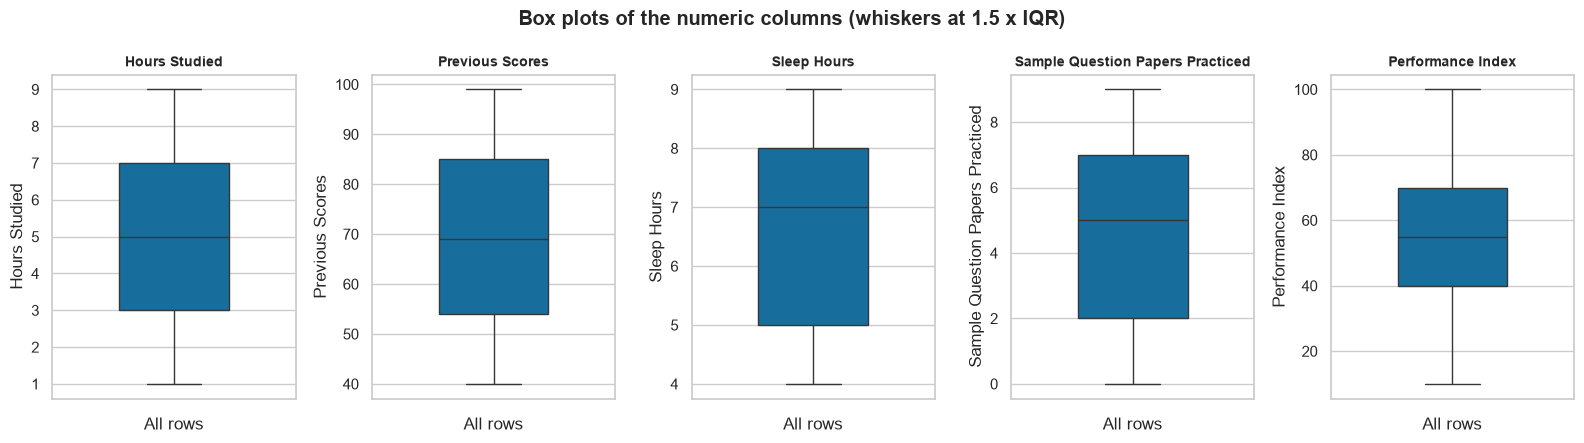

In [16]:
rows = []
for col in num_cols:
    s = df[col]
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    z = (s - s.mean()) / s.std()
    rows.append({"column": col, "Q1": q1, "Q3": q3, "IQR": iqr,
                 "lower fence": lo, "upper fence": hi,
                 "observed min": s.min(), "observed max": s.max(),
                 "IQR outliers": int(((s < lo) | (s > hi)).sum()),
                 "|z| > 3": int((z.abs() > 3).sum())})
outlier_table = pd.DataFrame(rows).set_index("column")
display(outlier_table)
save_table(outlier_table, "regression_outlier_check", floatfmt=".2f")

fig, axes = plt.subplots(1, len(num_cols), figsize=(3.2 * len(num_cols), 4.5))
for ax, col in zip(axes, num_cols):
    sns.boxplot(y=df[col], ax=ax, width=0.45, color=sns.color_palette("colorblind")[0])
    ax.set_title(col, fontsize=10)
    ax.set_xlabel("All rows")
    ax.set_ylabel(col)
fig.suptitle("Box plots of the numeric columns (whiskers at 1.5 x IQR)", fontweight="bold")
finalize(fig, "regression_outlier_boxplots")
plt.show()

### Technical Result
*Generated from the computation above; it updates automatically when the notebook is re-run.*

In [17]:
display(Markdown("\n".join(
    [f"- {c}: IQR outliers = {int(r['IQR outliers'])}, |z| > 3 = {int(r['|z| > 3'])} "
     f"(observed range {r['observed min']:g}–{r['observed max']:g}; fences {r['lower fence']:g} / {r['upper fence']:g})."
     for c, r in outlier_table.iterrows()]
)))

- Hours Studied: IQR outliers = 0, |z| > 3 = 0 (observed range 1–9; fences -3 / 13).
- Previous Scores: IQR outliers = 0, |z| > 3 = 0 (observed range 40–99; fences 7.5 / 131.5).
- Sleep Hours: IQR outliers = 0, |z| > 3 = 0 (observed range 4–9; fences 0.5 / 12.5).
- Sample Question Papers Practiced: IQR outliers = 0, |z| > 3 = 0 (observed range 0–9; fences -5.5 / 14.5).
- Performance Index: IQR outliers = 0, |z| > 3 = 0 (observed range 10–100; fences -5 / 115).

> ### ✍️ TEAM ANALYSIS REQUIRED — `REG-B1-OUTLIERS`: Outlier decision
> **Author:** _(write your name)_
>
> Write this in your own words, based on the output above. Course guideline 7.5 does not allow
> generative-AI tools to write analysis or interpretation.
>
> - Did either rule flag any values? Point to the numbers in the table.
> - What is your treatment decision (keep, cap, remove) and why?
> - Which of the ten models would be most sensitive to outliers if there were any, and why?
>
> *When done, replace this whole cell with your answer under the heading `### Team analysis — REG-B1-OUTLIERS`.*

## 14. Correlation heatmap  *(rubric A2)*

**What:** the Pearson correlation between every pair of numeric columns and the target.
`Extracurricular Activities` is included as a temporary 0/1 indicator (Yes = 1) **for this plot only**;
the real encoding happens inside the pipeline in section 18.

**Why:** correlations with the target hint at which features carry predictive signal; correlations
*between features* (multicollinearity) affect how linear-model coefficients can be interpreted.

**Concept:** Pearson's *r* measures only *linear* association (−1 to +1). A feature can matter through
a non-linear relationship and still show a small *r*, which is why section 15 also plots the
relationships directly.

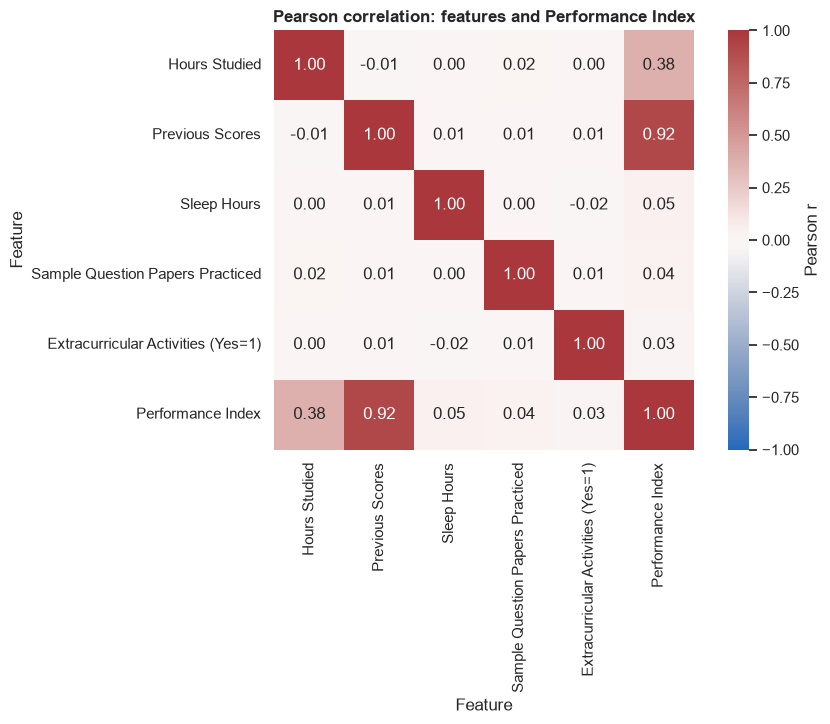

,r with Performance Index
column,
Previous Scores,0.9151
Hours Studied,0.3753
Sleep Hours,0.0504
Sample Question Papers Practiced,0.0434
Extracurricular Activities (Yes=1),0.0261


In [18]:
corr_frame = df[num_cols].copy()
corr_frame[f"{cat} (Yes=1)"] = (df[cat] == "Yes").astype(int)     # temporary, plot only
corr_frame = corr_frame[[c for c in corr_frame.columns if c != target] + [target]]

from src.plotting import correlation_heatmap
fig = correlation_heatmap(corr_frame, "Pearson correlation: features and Performance Index")
finalize(fig, "regression_correlation_heatmap")
plt.show()

corr_with_target = corr_frame.corr()[target].drop(target).sort_values(key=abs, ascending=False)
corr_with_target.rename("r with Performance Index").to_frame().round(4)

### Technical Result
*Generated from the computation above; it updates automatically when the notebook is re-run.*

In [19]:
inter = corr_frame.drop(columns=target).corr().where(~np.eye(len(corr_frame.columns) - 1, dtype=bool)).abs()
pair = inter.stack().idxmax()
display(Markdown("\n".join(
    [f"- r with {target}: " + "; ".join(f"{k} = {v:.4f}" for k, v in corr_with_target.items()) + "."]
    + [f"- Largest |r| between two input features: {inter.stack().max():.4f} ({pair[0]} and {pair[1]})."]
)))

- r with Performance Index: Previous Scores = 0.9151; Hours Studied = 0.3753; Sleep Hours = 0.0504; Sample Question Papers Practiced = 0.0434; Extracurricular Activities (Yes=1) = 0.0261.
- Largest |r| between two input features: 0.0240 (Sleep Hours and Extracurricular Activities (Yes=1)).

> ### ✍️ TEAM ANALYSIS REQUIRED — `REG-A3-CORRELATION`: Correlation heatmap
> **Author:** _(write your name)_
>
> Write this in your own words, based on the output above. Course guideline 7.5 does not allow
> generative-AI tools to write analysis or interpretation.
>
> - Which features have the strongest linear relationship with the target, and which have almost none?
> - Are any features strongly correlated with each other? What would that mean for interpreting linear-model coefficients?
> - Should a feature with a near-zero correlation be dropped? Why or why not?
>
> *When done, replace this whole cell with your answer under the heading `### Team analysis — REG-A3-CORRELATION`.*

## 15. Feature–target relationships  *(rubric A2)*

**What:** two scatter plots of numeric features against the target, and box plots of the target for
each value of the remaining features.

**Why:** a correlation coefficient is a single number; a scatter plot shows the *form* of the
relationship (linear, curved, fan-shaped, clustered). Because the features are discrete, points are
drawn with a small random horizontal jitter (seeded) so that overlapping points become visible — the
jitter is only for display.

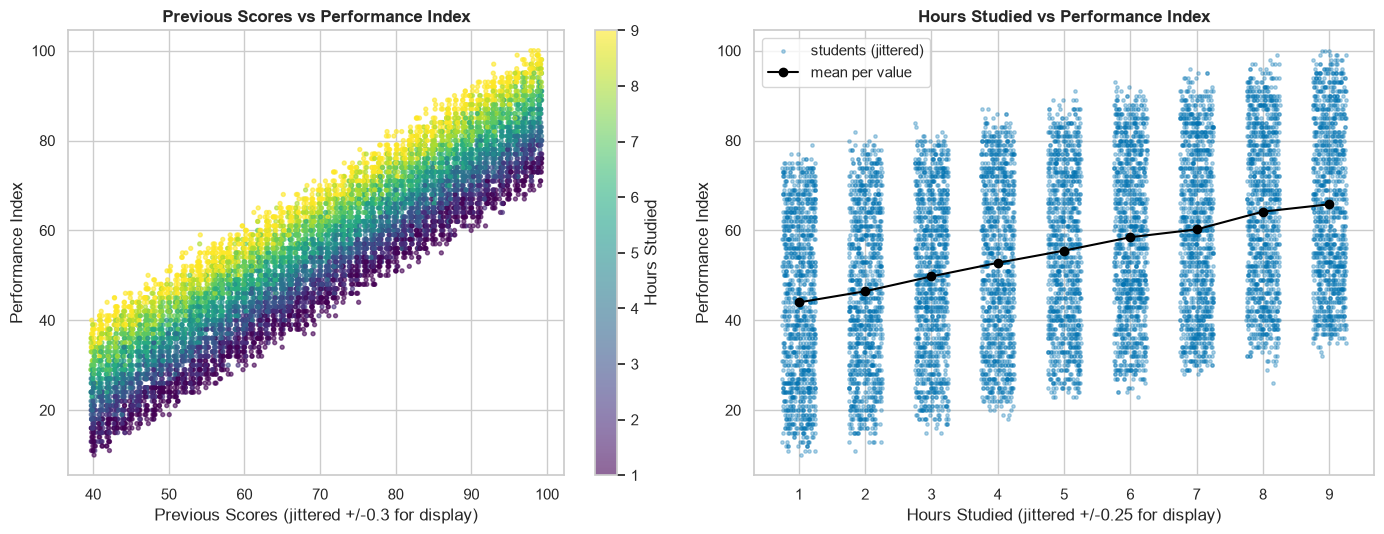

In [20]:
rng = np.random.default_rng(config.RANDOM_STATE)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
ax = axes[0]
points = ax.scatter(df["Previous Scores"] + rng.uniform(-0.3, 0.3, len(df)), df[target],
                    c=df["Hours Studied"], cmap="viridis", s=8, alpha=0.6)
cbar = fig.colorbar(points, ax=ax)
cbar.set_label("Hours Studied")
ax.set_title("Previous Scores vs Performance Index")
ax.set_xlabel("Previous Scores (jittered +/-0.3 for display)")
ax.set_ylabel("Performance Index")

ax = axes[1]
ax.scatter(df["Hours Studied"] + rng.uniform(-0.25, 0.25, len(df)), df[target],
           s=6, alpha=0.3, label="students (jittered)")
means = df.groupby("Hours Studied")[target].mean()
ax.plot(means.index, means.values, color="black", marker="o", label="mean per value")
ax.set_xticks(sorted(df["Hours Studied"].unique()))
ax.set_title("Hours Studied vs Performance Index")
ax.set_xlabel("Hours Studied (jittered +/-0.25 for display)")
ax.set_ylabel("Performance Index")
ax.legend()
finalize(fig, "regression_scatter_feature_target")
plt.show()

**The remaining features.** Sleep Hours and Sample Question Papers Practiced have few distinct values and Extracurricular Activities is categorical, so the target's distribution is shown per value (box plots) rather than as a scatter plot.

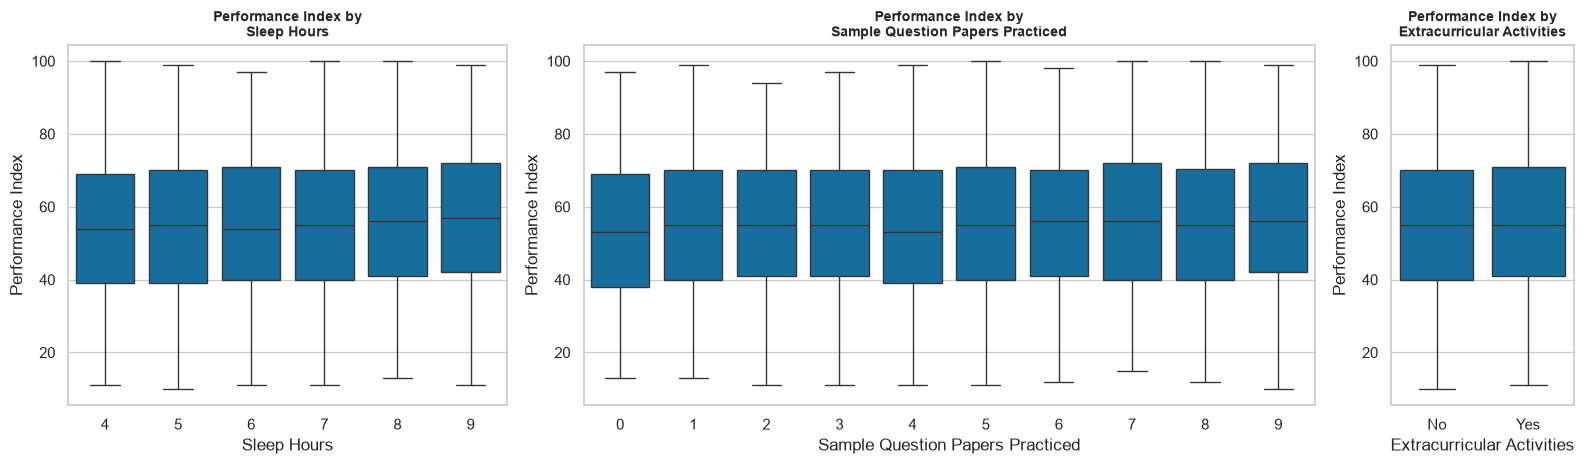

,count,mean,median,std
Extracurricular Activities,,,,
No,4986,54.721,55.0,19.147
Yes,4887,55.723,55.0,19.260


In [21]:
others = ["Sleep Hours", "Sample Question Papers Practiced", cat]
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), gridspec_kw={"width_ratios": [6, 10, 2.5]})
for ax, col in zip(axes, others):
    order = ["No", "Yes"] if col == cat else None
    sns.boxplot(data=df, x=col, y=target, order=order, ax=ax, color=sns.color_palette("colorblind")[0], fliersize=2)
    ax.set_title(f"Performance Index by\n{col}", fontsize=10)
    ax.set_xlabel(col)
    ax.set_ylabel("Performance Index")
finalize(fig, "regression_boxplots_by_feature")
plt.show()

df.groupby(cat)[target].agg(["count", "mean", "median", "std"]).round(3)

### Technical Result
*Generated from the computation above; it updates automatically when the notebook is re-run.*

In [22]:
mean_by_hours = df.groupby("Hours Studied")[target].mean()
display(Markdown("\n".join([
    f"- Mean Performance Index at Hours Studied = {mean_by_hours.index.min()}: {mean_by_hours.iloc[0]:.2f}; "
    f"at {mean_by_hours.index.max()}: {mean_by_hours.iloc[-1]:.2f}.",
    "- Median Performance Index by Sleep Hours: " + ", ".join(f"{k} = {v:g}" for k, v in df.groupby("Sleep Hours")[target].median().items()) + ".",
    "- Median Performance Index by Extracurricular Activities: " + ", ".join(f"{k} = {v:g}" for k, v in df.groupby(cat)[target].median().items()) + ".",
])))

- Mean Performance Index at Hours Studied = 1: 43.98; at 9: 65.81.
- Median Performance Index by Sleep Hours: 4 = 54, 5 = 55, 6 = 54, 7 = 55, 8 = 56, 9 = 57.
- Median Performance Index by Extracurricular Activities: No = 55, Yes = 55.

> ### ✍️ TEAM ANALYSIS REQUIRED — `REG-A3-RELATIONSHIPS`: Feature–target relationships
> **Author:** _(write your name)_
>
> Write this in your own words, based on the output above. Course guideline 7.5 does not allow
> generative-AI tools to write analysis or interpretation.
>
> - What form do the relationships in the two scatter plots take (linear, curved, none)? How does the colouring by Hours Studied add information?
> - Do Sleep Hours, Sample Question Papers Practiced or Extracurricular Activities visibly shift the target distribution?
> - Based on these plots, what kind of model (linear vs. non-linear) do you expect to work well, and why? (A hypothesis to test in section 20, not a conclusion.)
>
> *When done, replace this whole cell with your answer under the heading `### Team analysis — REG-A3-RELATIONSHIPS`.*

## 16. Leakage and identifier analysis

**What:** check every column for three problems:

| Problem | Test used here |
|---|---|
| **Identifier** (e.g. a student ID) | a column with a distinct value in (almost) every row |
| **Target leakage** (a column that records the answer or is computed from it) | a near-perfect correlation with the target (\|r\| ≥ 0.99), or a name/meaning that describes the outcome |
| **Algebraic redundancy** (a feature computable from other features) | R² of predicting that feature from all the other features with least squares |

**Why:** an identifier lets a model memorise rows; a leakage column produces excellent test scores
that are useless in practice; an exactly redundant feature double-counts information and makes
linear coefficients unstable.

The redundancy check is a *diagnostic* on the de-duplicated data (like the correlation matrix); its
result is not used to fit any transformer.

In [23]:
X_diag = df[features].copy()
X_diag[cat] = (X_diag[cat] == "Yes").astype(int)          # temporary 0/1 for the diagnostic only

def r2_from_others(frame, col):
    others = frame.drop(columns=col).to_numpy(dtype=float)
    A = np.column_stack([np.ones(len(frame)), others])
    coef, *_ = np.linalg.lstsq(A, frame[col].to_numpy(dtype=float), rcond=None)
    resid = frame[col].to_numpy(dtype=float) - A @ coef
    return 1 - resid.var() / frame[col].var(ddof=0)

leak = pd.DataFrame({
    "n_unique": df[features].nunique(),
    "unique ratio": (df[features].nunique() / len(df)).round(4),
    "|r| with target": X_diag.apply(lambda s: abs(np.corrcoef(s, df[target])[0, 1])).round(4),
    "R2 from other features": [round(r2_from_others(X_diag, c), 4) for c in features],
})
leak["identifier?"] = np.where(leak["unique ratio"] > 0.95, "YES", "no")
leak["leakage flag (|r| >= 0.99)?"] = np.where(leak["|r| with target"] >= 0.99, "YES", "no")
leak["redundant (R2 >= 0.99)?"] = np.where(leak["R2 from other features"] >= 0.99, "YES", "no")
display(leak)
save_table(leak, "regression_leakage_identifier_check")

print("Columns excluded from modelling:", contract.excluded or "none")

,n_unique,unique ratio,|r| with target,R2 from other features,identifier?,leakage flag (|r| >= 0.99)?,redundant (R2 >= 0.99)?
column,,,,,,,
Hours Studied,9,0.0009,0.3753,0.0004,no,no,no
Previous Scores,60,0.0061,0.9151,0.0003,no,no,no
Sleep Hours,6,0.0006,0.0504,0.0007,no,no,no
Sample Question Papers Practiced,10,0.0010,0.0434,0.0005,no,no,no
Extracurricular Activities,2,0.0002,0.0261,0.0009,no,no,no


Columns excluded from modelling: none


### Technical Result
*Generated from the computation above; it updates automatically when the notebook is re-run.*

In [24]:
display(Markdown("\n".join([
    f"- Identifier-like columns (unique ratio > 0.95): {int((leak['identifier?'] == 'YES').sum())}.",
    f"- Columns with |r| >= 0.99 with the target: {int((leak['leakage flag (|r| >= 0.99)?'] == 'YES').sum())} "
    f"(largest |r| = {leak['|r| with target'].max():.4f}, {leak['|r| with target'].idxmax()}).",
    f"- Largest R² of one feature predicted from the others: {leak['R2 from other features'].max():.4f}.",
    f"- Columns excluded from modelling: {len(contract.excluded)}.",
])))

- Identifier-like columns (unique ratio > 0.95): 0.
- Columns with |r| >= 0.99 with the target: 0 (largest |r| = 0.9151, Previous Scores).
- Largest R² of one feature predicted from the others: 0.0009.
- Columns excluded from modelling: 0.

> ### ✍️ TEAM ANALYSIS REQUIRED — `REG-LEAKAGE`: Leakage and identifiers
> **Author:** _(write your name)_
>
> Write this in your own words, based on the output above. Course guideline 7.5 does not allow
> generative-AI tools to write analysis or interpretation.
>
> - Do any columns behave like an identifier, a leakage column or a redundant feature? Use the table.
> - Every input column here is kept. Explain, in your own words, why none needs to be excluded — or argue for excluding one.
>
> *When done, replace this whole cell with your answer under the heading `### Team analysis — REG-LEAKAGE`.*

## 17. Train/test split  *(rubric B2)*

**What:** split the de-duplicated data **once** into 80 % training and 20 % test data with
`random_state=42`. Every model in this notebook uses exactly this split.

**Why stratify a continuous target?** The rubric asks for a stratified split. Stratification is defined
for classes, so the target is cut into **10 quantile bins only to build the split**: each tenth of the
score range is represented in train and test in the same proportion. The bins are **not** a feature and
the target values are **not** changed. The setting is `config.REGRESSION_STRATIFY_BINS` (set it to
`None` for a plain random split) — see `docs/clarifications.md`, C1.

**Concept — held-out test set:** the test rows are set aside and used only once, for the final
evaluation. Every fitted step (imputation values, scaling statistics, hyperparameters) is learned from
the training rows only.

In [25]:
from src.preprocessing import make_stratify_bins, split_regression

show_source(split_regression)

def split_regression(X: pd.DataFrame, y: pd.Series, n_bins: int | None = None):
    """80:20 split for regression, optionally stratified on target quantile bins.

    ``n_bins`` defaults to ``config.REGRESSION_STRATIFY_BINS``; pass 0 or set
    that config value to None to use a plain random split.
    Returns X_train, X_test, y_train, y_test.
    """
    if n_bins is None:
        n_bins = config.REGRESSION_STRATIFY_BINS
    strata = make_stratify_bins(y, n_bins) if n_bins else None
    return train_test_split(
        X, y,
        test_size=config.TEST_SIZE,
        random_state=config.RANDOM_STATE,
        stratify=strata,
    )



**Performing the split.** `X` holds only the five input columns and `y` the unmodified target; the assertions confirm that no row is in both sets.

In [26]:
X = df[features]                      # the five input columns only
y = df[target]                        # Performance Index, unmodified

X_train, X_test, y_train, y_test = split_regression(X, y)

assert X_train.index.intersection(X_test.index).empty, "a row is in both train and test"
assert list(X_train.columns) == features, "only the five input columns may be in X"
print(f"Training set: {X_train.shape[0]:,} rows ({X_train.shape[0] / len(X):.1%})")
print(f"Test set:     {X_test.shape[0]:,} rows ({X_test.shape[0] / len(X):.1%})")
print(f"Features ({X_train.shape[1]}): {features}")

Training set: 7,898 rows (80.0%)
Test set:     1,975 rows (20.0%)
Features (5): ['Hours Studied', 'Previous Scores', 'Sleep Hours', 'Sample Question Papers Practiced', 'Extracurricular Activities']


**Checking the split.** If stratification worked, each target bin makes up the same share of the
training and the test set, and the summary statistics of the target are close in both.

In [27]:
bins = make_stratify_bins(y, config.REGRESSION_STRATIFY_BINS)
bin_share = pd.DataFrame({
    "train share": bins.loc[y_train.index].value_counts(normalize=True).sort_index(),
    "test share": bins.loc[y_test.index].value_counts(normalize=True).sort_index(),
}).round(4)
bin_share.index.name = "target quantile bin"
display(bin_share)

split_summary = pd.DataFrame({"train": y_train.describe(), "test": y_test.describe()}).round(3)
display(split_summary)
save_table(split_summary, "regression_split_target_summary", floatfmt=".3f")

from src.preprocessing import row_overlap_report
overlap = row_overlap_report(X_train, X_test)
print("Test rows whose five input values also occur in the training set "
      "(reported, not removed - see section 9):")
print(overlap)

,train share,test share
target quantile bin,,
0,0.1007,0.1008
1,0.1055,0.1058
2,0.1015,0.1013
3,0.1014,0.1013
4,0.0950,0.0947
5,0.1015,0.1018
6,0.0979,0.0977
7,0.1117,0.1119
8,0.0895,0.0896


,train,test
count,7898.000,1975.000
mean,55.224,55.189
std,19.209,19.210
min,10.000,11.000
25%,40.000,40.000
50%,55.000,55.000
75%,70.000,71.000
max,100.000,97.000


Test rows whose five input values also occur in the training set (reported, not removed - see section 9):
{'test_rows': 1975, 'test_rows_seen_in_train': 205, 'pct_test_rows_seen_in_train': 10.38}


**Recording the split.** The row indices are saved to the git-ignored `data/processed/` folder so that validation can confirm every saved model was evaluated on exactly these test rows.

In [28]:
# Save the split row indices so later checks can rebuild exactly the same split.
import json
split_file = config.PROCESSED_DIR / "regression_split_indices.json"
split_file.write_text(json.dumps({"train": X_train.index.tolist(), "test": X_test.index.tolist(),
                                  "random_state": config.RANDOM_STATE,
                                  "stratify_bins": config.REGRESSION_STRATIFY_BINS}), encoding="utf-8")
print(f"Split indices saved to {split_file.relative_to(ROOT)}")

Split indices saved to data\processed\regression_split_indices.json


## 18. Preprocessing strategy  *(rubric B2)*

**What:** define how each input column is transformed before it reaches a model.

| Column(s) | Missing values | Encoding / scaling | Reason |
|---|---|---|---|
| `Hours Studied`, `Previous Scores`, `Sleep Hours`, `Sample Question Papers Practiced` | median imputation | `StandardScaler` (mean 0, std 1) | numeric; scale-sensitive models need comparable ranges |
| `Extracurricular Activities` | most-frequent imputation | one-hot → a single 0/1 column (`drop="if_binary"`) | categorical; models need numbers; a binary category needs only one column |
| `Performance Index` (target) | — | **not transformed** | metrics must be reported in the original units |

**Which models need scaling?** Ridge, Lasso and ElasticNet (the penalty treats all coefficients
equally, so features must be on one scale), SVR and KNN (distance-based), and Polynomial Regression
(squared terms of unscaled features become very large). Linear Regression's *predictions* do not change
with scaling, but its coefficients become comparable. Tree models (Decision Tree, Random Forest,
Gradient Boosting) split on thresholds and are **unaffected** by scaling. All ten models nevertheless
share **one** preprocessor so that they are trained on the same preprocessed data (course guideline 3.1);
for the trees the scaling is a harmless no-op (`docs/clarifications.md`, C2). The binary one-hot column
is left as 0/1 and is not scaled.

**Why inside a `Pipeline`:** `ColumnTransformer` + `Pipeline` guarantee that imputers, the encoder and
the scaler are **fitted on the training data only** and merely *applied* to the test data — including
inside every cross-validation fold later. Nothing is fitted on the full dataset.

In [29]:
from src.preprocessing import build_regression_preprocessor

show_source(build_regression_preprocessor)

def build_regression_preprocessor(
    numeric: list[str] | tuple[str, ...],
    categorical: list[str] | tuple[str, ...],
    scale: bool = True,
) -> ColumnTransformer:
    """Imputation + encoding (+ optional scaling) for tabular regression data.

    numeric     -> median imputation -> StandardScaler (if ``scale``)
    categorical -> most-frequent imputation -> one-hot (binary columns become one 0/1 column)
    """
    numeric_steps = [("impute", SimpleImputer(strategy="median"))]
    if scale:
        numeric_steps.append(("scale", StandardScaler()))
    categorical_steps = [
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(drop="if_binary", handle_unknown="ignore", sparse_output=False)),
    ]
    return ColumnTransformer(
        [
            ("num", Pipeline(numeric_steps), list(numeric)),
            ("cat", Pipeline(categorical_steps), list(categorical)),
        ],
        remainder="drop",
        verbose_feature_names_out=False

**Building the preprocessor.** `NUMERIC` and `CATEGORICAL` come from the dataset contract; the unfitted `ColumnTransformer` is displayed as a diagram of its steps.

In [30]:
from sklearn import set_config
set_config(display="diagram")

NUMERIC = list(contract.numeric_features)
CATEGORICAL = list(contract.categorical_features)

preprocessor = build_regression_preprocessor(NUMERIC, CATEGORICAL, scale=True)
preprocessor          # unfitted: shows the structure only

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. ``""{feature_name}__{transformer_name}""``. See :meth:`str.format` method from the standard library for more info... versionadded:: 1.0.. versionchanged:: 1.6 `verbose_feature_names_out` can be a callable or a string to be formatted.",False
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The

**Demonstration: the preprocessor learns from the training set only.** Below it is fitted on
`X_train` alone. The scaler's stored means must equal the *training* means (not the full-data means);
transformed training columns then have mean ≈ 0 and standard deviation ≈ 1, while the test columns do
not match exactly — because the test set's own statistics were never used.

In [31]:
demo = build_regression_preprocessor(NUMERIC, CATEGORICAL, scale=True).fit(X_train)
scaler = demo.named_transformers_["num"].named_steps["scale"]

learned = pd.DataFrame({
    "scaler mean (learned)": scaler.mean_,
    "training-set mean": X_train[NUMERIC].mean().values,
    "full-data mean": X[NUMERIC].mean().values,
}, index=NUMERIC)
display(learned.round(4))
assert np.allclose(scaler.mean_, X_train[NUMERIC].mean().values), "scaler was not fitted on training data only"

Z_train = pd.DataFrame(demo.transform(X_train), columns=demo.get_feature_names_out(), index=X_train.index)
Z_test = pd.DataFrame(demo.transform(X_test), columns=demo.get_feature_names_out(), index=X_test.index)
check = pd.DataFrame({"train mean": Z_train.mean(), "train std": Z_train.std(ddof=0),
                      "test mean": Z_test.mean(), "test std": Z_test.std(ddof=0)}).round(4)
display(check)
print("Output columns:", list(demo.get_feature_names_out()))
Z_train.head()

,scaler mean (learned),training-set mean,full-data mean
Hours Studied,4.9915,4.9915,4.9921
Previous Scores,69.4709,69.4709,69.4411
Sleep Hours,6.5218,6.5218,6.5317
Sample Question Papers Practiced,4.5999,4.5999,4.5830


,train mean,train std,test mean,test std
Hours Studied,0.0000,1.0,0.0011,1.0195
Previous Scores,-0.0000,1.0,-0.0086,0.9945
Sleep Hours,-0.0000,1.0,0.0291,0.9994
Sample Question Papers Practiced,-0.0000,1.0,-0.0295,1.0030
Extracurricular Activities_Yes,0.4947,0.5,0.4962,0.5000


Output columns: ['Hours Studied', 'Previous Scores', 'Sleep Hours', 'Sample Question Papers Practiced', 'Extracurricular Activities_Yes']


,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Extracurricular Activities_Yes
8099,1.166609,-0.776704,1.459777,-0.209377,0.0
3987,0.003290,0.664746,-1.485433,-1.256440,0.0
3731,-0.772257,1.241326,0.281693,0.488665,1.0
4339,-0.772257,0.953036,0.281693,1.186707,1.0
1624,1.166609,-1.237968,0.281693,-1.256440,1.0


## 19. Feature engineering  *(rubric B3)*

**What:** the rubric requires at least one engineered feature with a written justification.

**How it works in this project:**
1. The team registers a feature in `src/feature_engineering.py` (section *TEAM REGISTRATIONS*), with
   the new column name(s), a row-wise function and a written justification.
2. A pipeline step, `AddRegisteredFeatures("regression")`, adds the registered columns **before**
   preprocessing, so the feature is created identically for training, cross-validation and test rows.
3. Engineered columns are treated as numeric (imputed and scaled) by the preprocessor below.
4. In section 20 every model is evaluated with the complete pipeline; the with/without comparison for
   the registered feature is reported there.

**Leakage rule:** the feature function must be *row-wise* — each new value may use only the same row's
inputs, never a mean, rank or quantile computed across rows (that would learn from the test set).

Nothing is registered yet — this is deliberately left to the team. With nothing registered, the step
passes the data through unchanged.

In [32]:
from sklearn.pipeline import Pipeline
from src import feature_engineering as fe

fe_status = fe.status()["regression"]
print("Registered regression features:", fe_status["features"] or "none yet")
print("Rubric B3 complete:", fe_status["complete"])

ENGINEERED = [col for f in fe.registered_features("regression") for col in f.new_columns]
PIPELINE_NUMERIC = NUMERIC + ENGINEERED        # engineered columns are imputed and scaled like numeric inputs


def build_regression_pipeline(model, scale=True, engineered=True):
    """The full pipeline every regression model uses: add features -> preprocess -> model.

    scale=False is used only to DEMONSTRATE the effect of scaling (SVR, KNN in section 20);
    engineered=False is used only to measure the effect of the team's engineered feature.
    """
    numeric = PIPELINE_NUMERIC if engineered else NUMERIC
    return Pipeline([
        ("add_features", fe.AddRegisteredFeatures("regression")),
        ("preprocess", build_regression_preprocessor(numeric, CATEGORICAL, scale=scale)),
        ("model", model),
    ])


# Check the feature + preprocessing part end to end (fitted on training rows only, no model yet).
feature_part = Pipeline(build_regression_pipeline(model=None).steps[:-1]).fit(X_train)
print(f"Transformed training matrix: {feature_part.transform(X_train).shape}   "
      f"test matrix: {feature_part.transform(X_test).shape}")
print("Columns entering the models:", list(feature_part.named_steps["preprocess"].get_feature_names_out()))

Registered regression features: none yet
Rubric B3 complete: False
Transformed training matrix: (7898, 5)   test matrix: (1975, 5)
Columns entering the models: ['Hours Studied', 'Previous Scores', 'Sleep Hours', 'Sample Question Papers Practiced', 'Extracurricular Activities_Yes']


> **Rubric B3 status: TEAM INPUT REQUIRED — not complete.** No engineered feature has been registered,
> and `scripts/validate_project.py` reports this item as PENDING until one is registered *with* a
> written justification. The machinery is ready; the choice and the reasoning are the team's.

**Template** (to be added by the team at the bottom of `src/feature_engineering.py`; the names below are
placeholders, not a suggested feature):

```python
register_feature(RegisteredFeature(
    track="regression",
    name="<short_name>",
    new_columns=("<New Column>",),
    function=lambda X: pd.DataFrame({"<New Column>": <row-wise expression using X[...]>}, index=X.index),
    justification="<the team's own reasoning>",
    author="<student name>",
))
```

After registering, re-run the notebook: sections 19 and 20.12 then show the new column and the
with/without comparison automatically.

> ### ✍️ TEAM ANALYSIS REQUIRED — `REG-B3`: Engineered feature and justification
> **Author:** _(write your name)_
>
> Write this in your own words, based on the output above. Course guideline 7.5 does not allow
> generative-AI tools to write analysis or interpretation.
>
> - Which feature will you create, from which columns, and why might it help? Base the reasoning on sections 11–16.
> - Is your feature computed row by row only, so it cannot leak test information?
> - After section 20 runs: did the feature actually help? Report the numbers, including if it did not.
>
> *When done, replace this whole cell with your answer under the heading `### Team analysis — REG-B3`.*

## 20. The ten regression algorithms  *(rubric C1, C2)*

**What:** train each of the ten algorithms required by course guideline 3.1 and evaluate it on the
held-out test set.

**Shared protocol — identical for every model:**
* the **same split**: fitted on `X_train, y_train` (7,898 rows), evaluated on `X_test, y_test` (1,975 rows);
* the **same pipeline** from section 19: add registered features → impute/encode/scale → model;
* **baseline hyperparameters**: each model is first trained with scikit-learn's default settings
  (plus `random_state=42` where the estimator accepts one). These baseline results form the comparison
  table in 20.11. The only exception is Polynomial Regression, whose degree is chosen by training-set
  cross-validation because the guideline asks for a comparison of degrees;
* **metrics** on the test set, in Performance Index points: R², RMSE, MAE (defined in section 2).

**Hyperparameter-effect curves (model evaluation, not EDA).** Each algorithm section shows how the
hyperparameter named in the guideline changes model performance. These curves are *model evaluation*:
they are computed with **5-fold cross-validation on the training set only**, and the test set is never
used for them. They describe each model; they do not change the baseline settings. (The exploratory
data analysis in sections 11–16 is ordinary descriptive analysis and does not use cross-validation.)
Formal tuning with `GridSearchCV` and before/after results is in section 21.

In [33]:
import time
from IPython.display import Markdown
from sklearn.base import clone
from sklearn.metrics import r2_score
from sklearn.model_selection import GridSearchCV, KFold, cross_validate, validation_curve

from src.evaluation import regression_metrics, save_table
from src.plotting import feature_importance, validation_curve_plot

# One cross-validation splitter for every exploration on the training set.
CV = KFold(n_splits=config.CV_FOLDS, shuffle=True, random_state=config.RANDOM_STATE)

results = {}   # model name -> metrics on the held-out test set
fitted = {}    # model name -> fitted pipeline


def evaluate(name, pipe, y_pred, fit_seconds):
    """Score test-set predictions (original units) and store them for the comparison table."""
    row = regression_metrics(y_test, y_pred)                    # R2, RMSE, MAE
    row["Train R2"] = r2_score(y_train, pipe.predict(X_train))  # for spotting over-fitting
    row["Fit time (s)"] = round(fit_seconds, 3)
    results[name], fitted[name] = row, pipe
    return pd.DataFrame([row], index=pd.Index([name], name="Model")).round(4)


def technical_result(name, *facts):
    """Print the factual results of one model as a bullet list (no interpretation)."""
    r = results[name]
    lines = [f"- Test set (n = {len(y_test):,}): **R² = {r['R2']:.4f}**, RMSE = {r['RMSE']:.4f}, "
             f"MAE = {r['MAE']:.4f} (Performance Index points).",
             f"- Training-set R² = {r['Train R2']:.4f} (train − test R² = {r['Train R2'] - r['R2']:+.4f}); "
             f"fit time = {r['Fit time (s)']:.3f} s."]
    display(Markdown("\n".join(lines + [f"- {f}" for f in facts])))


def explore(model, param, values, title, xlabel, log_x=False, marker_value=None, **pipe_kwargs):
    """5-fold CV curve of one hyperparameter on the TRAINING set (the test set is not used)."""
    pipe = build_regression_pipeline(model, **pipe_kwargs)
    train_sc, cv_sc = validation_curve(pipe, X_train, y_train, param_name=f"model__{param}",
                                       param_range=values, cv=CV, scoring="r2", n_jobs=-1)
    table = pd.DataFrame({param: [str(v) for v in values],
                          "train R2 (mean)": train_sc.mean(axis=1),
                          "CV R2 (mean)": cv_sc.mean(axis=1),
                          "CV R2 (std)": cv_sc.std(axis=1)}).round(4)
    fig = validation_curve_plot(values, train_sc, cv_sc, title, xlabel,
                                "R² (5-fold CV on the training set)", log_x=log_x, marker_value=marker_value)
    return table, fig


def coefficient_table(pipe):
    """Linear-model coefficients per 1 standard deviation and per 1 original unit of each input."""
    names = pipe.named_steps["preprocess"].get_feature_names_out()
    coef = np.asarray(pipe.named_steps["model"].coef_, dtype=float)
    scale = pipe.named_steps["preprocess"].named_transformers_["num"].named_steps["scale"].scale_
    per_unit = coef.copy()
    per_unit[:len(scale)] = coef[:len(scale)] / scale        # numeric columns were standardised
    return pd.DataFrame({"coef (per 1 std)": coef, "coef (per 1 original unit)": per_unit},
                        index=pd.Index(names, name="feature"))

## 20.1 Linear Regression

**What it is.** The baseline regression model: it predicts the target as a weighted sum of the inputs
plus a constant, *ŷ = b₀ + b₁x₁ + … + bₚxₚ*.

**How it works.**
1. Start from the training matrix *X* (after preprocessing) and the target *y*.
2. Choose the coefficients *b* that minimise the sum of squared errors Σ(yᵢ − ŷᵢ)² — *ordinary least squares*.
3. This has a closed-form solution, so no iterations, learning rate or random start are involved.
4. A prediction is the weighted sum of a new row's inputs.

**Why it is evaluated.** Guideline 3.1 names it the baseline; every other model has to justify its extra
complexity against it. Its coefficients are directly interpretable.

**Important hyperparameters.** Essentially none (`fit_intercept=True` by default).

**Scaling.** Not needed for the *predictions* (they are identical with or without scaling), but with
standardised inputs the coefficients are comparable: each is the change in the target for a one
standard-deviation change in that input.

**Limitations.** Can only represent linear, additive relationships; sensitive to outliers (squared
error); coefficients become unstable when inputs are strongly correlated with each other.

In [34]:
from sklearn.linear_model import LinearRegression

lin_reg = build_regression_pipeline(LinearRegression())      # model creation inside the shared pipeline
lin_reg

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('add_features', ...), ('preprocess', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,track,'regression'
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_

**Training and evaluation.** Fit on the training rows only, predict the held-out test rows, and record R², RMSE and MAE (the same three steps are used for every model).

In [35]:
t0 = time.perf_counter()
lin_reg.fit(X_train, y_train)            # learns preprocessing + coefficients from the training rows only
fit_s = time.perf_counter() - t0

lin_pred = lin_reg.predict(X_test)       # predictions for the held-out test set
evaluate("Linear Regression", lin_reg, lin_pred, fit_s)

,R2,RMSE,MAE,Train R2,Fit time (s)
Model,,,,,
Linear Regression,0.9886,2.0525,1.6416,0.9887,0.01


**Coefficient table** — the fitted model, written out.

Intercept (b0): 54.9213


,coef (per 1 std),coef (per 1 original unit)
feature,,
Hours Studied,7.3649,2.8559
Previous Scores,17.6743,1.0191
Sleep Hours,0.8159,0.4806
Sample Question Papers Practiced,0.5535,0.1932
Extracurricular Activities_Yes,0.6111,0.6111


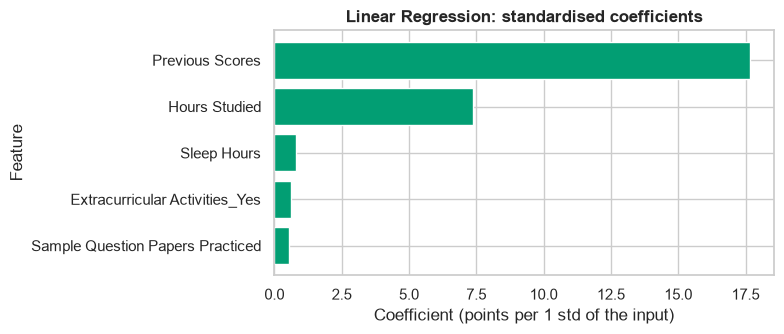

In [36]:
lin_coefs = coefficient_table(lin_reg)
print(f"Intercept (b0): {lin_reg.named_steps['model'].intercept_:.4f}")
display(lin_coefs.round(4))
save_table(lin_coefs, "regression_linear_coefficients")

fig = feature_importance(lin_coefs.index, lin_coefs["coef (per 1 std)"],
                         "Linear Regression: standardised coefficients", xlabel="Coefficient (points per 1 std of the input)")
finalize(fig, "regression_linear_coefficients")
plt.show()

### Technical Result
*Generated from the computation above; it updates automatically when the notebook is re-run.*

In [37]:
top = lin_coefs["coef (per 1 std)"].abs().idxmax()
technical_result(
    "Linear Regression",
    f"Intercept = {lin_reg.named_steps['model'].intercept_:.4f}.",
    f"Largest standardised coefficient: {top} ({lin_coefs.loc[top, 'coef (per 1 std)']:.4f} points per 1 std).",
    "Coefficients per original unit: " + "; ".join(f"{k} = {v:.4f}" for k, v in lin_coefs["coef (per 1 original unit)"].items()) + ".",
)

- Test set (n = 1,975): **R² = 0.9886**, RMSE = 2.0525, MAE = 1.6416 (Performance Index points).
- Training-set R² = 0.9887 (train − test R² = +0.0001); fit time = 0.010 s.
- Intercept = 54.9213.
- Largest standardised coefficient: Previous Scores (17.6743 points per 1 std).
- Coefficients per original unit: Hours Studied = 2.8559; Previous Scores = 1.0191; Sleep Hours = 0.4806; Sample Question Papers Practiced = 0.1932; Extracurricular Activities_Yes = 0.6111.

> ### ✍️ TEAM ANALYSIS REQUIRED — `REG-M1-LINEAR`: Linear Regression
> **Author:** _(write your name)_
>
> Interpret the output above in your own words (course guideline 7.5: no AI-written analysis).
>
> - What does each coefficient mean in plain words (per original unit)? Which inputs matter most?
> - How do the coefficient signs and sizes compare with what the correlation heatmap (section 14) suggested?
> - What does the gap (or lack of gap) between training and test R² tell you?
>
> *When done, replace this whole cell with your answer under the heading `### Team analysis — REG-M1-LINEAR`.*

## 20.2 Ridge Regression

**What it is.** Linear regression with an **L2 penalty** that discourages large coefficients.

**How it works.**
1. Minimise Σ(yᵢ − ŷᵢ)² **+ α · Σ bⱼ²** instead of the squared error alone.
2. The penalty term shrinks every coefficient towards zero; α sets how strongly.
3. α = 0 gives ordinary Linear Regression; α → ∞ drives all coefficients towards 0 (predicting the mean).
4. Coefficients shrink smoothly but never become exactly zero.

**Why it is evaluated.** Regularisation trades a little bias for lower variance; it helps when inputs are
correlated or the model over-fits. Guideline 3.1: "L2 regularisation; tune alpha".

**Important hyperparameters.** `alpha` (default 1.0). Formal tuning of α is in Phase 5; below, its
effect is shown with a coefficient path and a training-set CV curve.

**Scaling.** **Required.** The penalty treats all coefficients equally, so inputs must be on one scale —
otherwise features with large units would be penalised less.

**Limitations.** Still linear; does not perform feature selection; α must be chosen.

In [38]:
from sklearn.linear_model import Ridge

ridge = build_regression_pipeline(Ridge(alpha=1.0, random_state=config.RANDOM_STATE))   # scikit-learn default alpha

t0 = time.perf_counter()
ridge.fit(X_train, y_train)
fit_s = time.perf_counter() - t0

ridge_pred = ridge.predict(X_test)
evaluate("Ridge Regression", ridge, ridge_pred, fit_s)

,R2,RMSE,MAE,Train R2,Fit time (s)
Model,,,,,
Ridge Regression,0.9886,2.0524,1.6415,0.9887,0.01


**Regularisation effect.** The same pipeline is refitted on the training set for a range of α values;
the coefficient path shows how every coefficient shrinks as α grows, and the CV curve shows the effect on
cross-validated R².

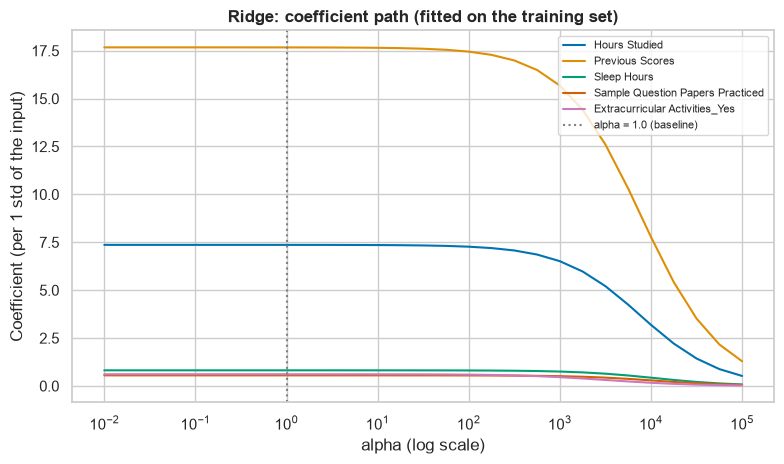

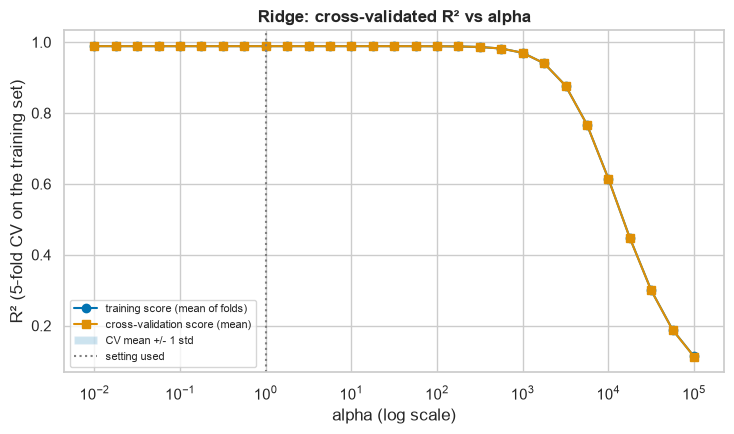

,alpha,train R2 (mean),CV R2 (mean),CV R2 (std)
0,0.01,0.9887,0.9887,0.0005
4,0.1,0.9887,0.9887,0.0005
8,1.0,0.9887,0.9887,0.0005
12,10.0,0.9887,0.9887,0.0005
16,100.0,0.9885,0.9884,0.0004
20,1000.0,0.9700,0.9699,0.0006
24,10000.0,0.6150,0.6148,0.0017
28,100000.0,0.1132,0.1128,0.0007


,Linear Regression,Ridge (alpha=1)
feature,,
Hours Studied,7.3649,7.3639
Previous Scores,17.6743,17.6720
Sleep Hours,0.8159,0.8159
Sample Question Papers Practiced,0.5535,0.5534
Extracurricular Activities_Yes,0.6111,0.6109


In [39]:
alphas = np.logspace(-2, 5, 29)
path = []
for a in alphas:
    p = clone(ridge).set_params(model__alpha=a).fit(X_train, y_train)
    path.append(p.named_steps["model"].coef_)
path = pd.DataFrame(path, index=alphas, columns=ridge.named_steps["preprocess"].get_feature_names_out())

fig, ax = plt.subplots(figsize=(8, 4.8))
for col in path.columns:
    ax.plot(path.index, path[col], label=col)
ax.axvline(1.0, color="grey", linestyle=":", label="alpha = 1.0 (baseline)")
ax.set_xscale("log")
ax.set_title("Ridge: coefficient path (fitted on the training set)")
ax.set_xlabel("alpha (log scale)")
ax.set_ylabel("Coefficient (per 1 std of the input)")
ax.legend(fontsize=8)
finalize(fig, "regression_ridge_coefficient_path")
plt.show()

ridge_curve, fig = explore(Ridge(random_state=config.RANDOM_STATE), "alpha", alphas,
                           "Ridge: cross-validated R² vs alpha", "alpha (log scale)", log_x=True, marker_value=1.0)
finalize(fig, "regression_ridge_alpha_curve")
plt.show()
display(ridge_curve.iloc[::4])

ridge_coefs = coefficient_table(ridge)
display(pd.DataFrame({"Linear Regression": lin_coefs["coef (per 1 std)"],
                      "Ridge (alpha=1)": ridge_coefs["coef (per 1 std)"]}).round(4))

### Technical Result
*Generated from the computation above; it updates automatically when the notebook is re-run.*

In [40]:
best = ridge_curve.loc[ridge_curve["CV R2 (mean)"].idxmax()]
technical_result(
    "Ridge Regression",
    f"Sum of |coefficients|: Ridge (alpha=1) = {ridge_coefs['coef (per 1 std)'].abs().sum():.4f} vs "
    f"Linear Regression = {lin_coefs['coef (per 1 std)'].abs().sum():.4f}.",
    f"Training-set CV R² ranges from {ridge_curve['CV R2 (mean)'].min():.4f} to {ridge_curve['CV R2 (mean)'].max():.4f} "
    f"across alpha = {alphas.min():g} … {alphas.max():g}; highest at alpha = {best['alpha']}.",
)

- Test set (n = 1,975): **R² = 0.9886**, RMSE = 2.0524, MAE = 1.6415 (Performance Index points).
- Training-set R² = 0.9887 (train − test R² = +0.0001); fit time = 0.010 s.
- Sum of |coefficients|: Ridge (alpha=1) = 27.0162 vs Linear Regression = 27.0197.
- Training-set CV R² ranges from 0.1128 to 0.9887 across alpha = 0.01 … 100000; highest at alpha = 0.01.

> ### ✍️ TEAM ANALYSIS REQUIRED — `REG-M2-RIDGE`: Ridge Regression
> **Author:** _(write your name)_
>
> Interpret the output above in your own words (course guideline 7.5: no AI-written analysis).
>
> - How does the coefficient path show the effect of regularisation? At what alpha does performance start to drop?
> - Why might Ridge perform almost the same as Linear Regression on this data (or differently)? Relate this to the feature correlations.
>
> *When done, replace this whole cell with your answer under the heading `### Team analysis — REG-M2-RIDGE`.*

## 20.3 Lasso Regression

**What it is.** Linear regression with an **L1 penalty**, which can set coefficients **exactly to zero**.

**How it works.**
1. Minimise (1 / 2n) Σ(yᵢ − ŷᵢ)² **+ α · Σ |bⱼ|**.
2. The absolute-value penalty has a "corner" at zero, so for large enough α some coefficients become
   exactly 0 — those inputs are dropped from the model (automatic feature selection).
3. It is solved iteratively by coordinate descent.

**Why it is evaluated.** Guideline 3.1: "L1 regularisation; observe feature sparsity" — Lasso shows which
inputs the data can do without.

**Important hyperparameters.** `alpha` (default 1.0): larger α → more zero coefficients.

**Scaling.** **Required**, for the same reason as Ridge.

**Limitations.** With correlated inputs it tends to keep one arbitrarily and drop the others; too large
an α removes useful features and under-fits.

In [41]:
from sklearn.linear_model import Lasso

lasso = build_regression_pipeline(Lasso(alpha=1.0, random_state=config.RANDOM_STATE))   # default alpha

t0 = time.perf_counter()
lasso.fit(X_train, y_train)
fit_s = time.perf_counter() - t0

lasso_pred = lasso.predict(X_test)
evaluate("Lasso Regression", lasso, lasso_pred, fit_s)

,R2,RMSE,MAE,Train R2,Fit time (s)
Model,,,,,
Lasso Regression,0.9806,2.676,2.1457,0.9804,0.014


**Zero and non-zero coefficients** at the baseline α, and how sparsity changes with α.

,coef (per 1 std),coef (per 1 original unit),status
feature,,,
Hours Studied,6.3637,2.4677,non-zero
Previous Scores,16.6804,0.9618,non-zero
Sleep Hours,0.0000,0.0000,ZERO (dropped)
Sample Question Papers Practiced,0.0000,0.0000,ZERO (dropped)
Extracurricular Activities_Yes,0.0000,0.0000,ZERO (dropped)


Zero coefficients: 3 of 5   non-zero: 2


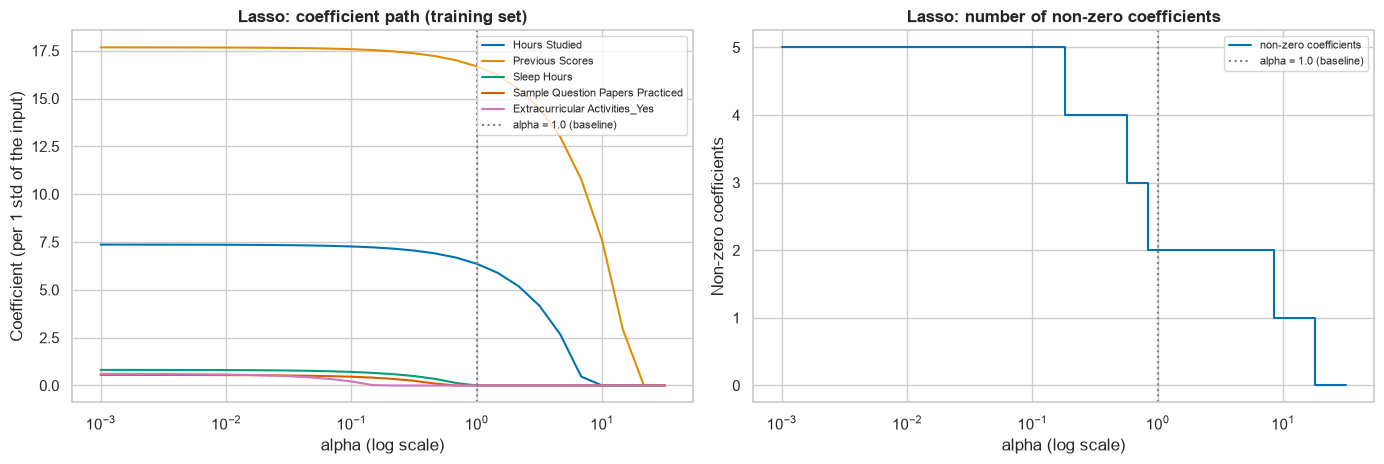

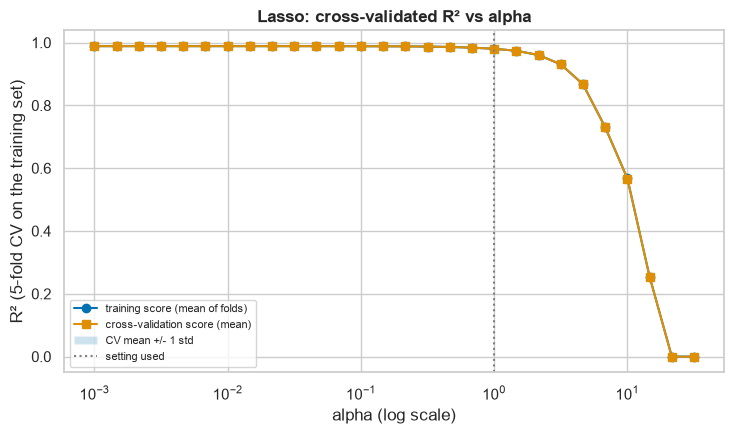

In [42]:
lasso_coefs = coefficient_table(lasso)
lasso_coefs["status"] = np.where(lasso_coefs["coef (per 1 std)"] == 0, "ZERO (dropped)", "non-zero")
display(lasso_coefs.round(4))
n_zero = int((lasso_coefs["coef (per 1 std)"] == 0).sum())
print(f"Zero coefficients: {n_zero} of {len(lasso_coefs)}   non-zero: {len(lasso_coefs) - n_zero}")

lasso_alphas = np.logspace(-3, 1.5, 28)
nonzero, coefs = [], []
for a in lasso_alphas:
    p = clone(lasso).set_params(model__alpha=a).fit(X_train, y_train)
    c = p.named_steps["model"].coef_
    coefs.append(c)
    nonzero.append(int(np.sum(c != 0)))
coefs = pd.DataFrame(coefs, index=lasso_alphas, columns=lasso_coefs.index)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
for col in coefs.columns:
    axes[0].plot(coefs.index, coefs[col], label=col)
axes[0].axvline(1.0, color="grey", linestyle=":", label="alpha = 1.0 (baseline)")
axes[0].set_xscale("log")
axes[0].set_title("Lasso: coefficient path (training set)")
axes[0].set_xlabel("alpha (log scale)")
axes[0].set_ylabel("Coefficient (per 1 std of the input)")
axes[0].legend(fontsize=8)
axes[1].step(lasso_alphas, nonzero, where="mid", label="non-zero coefficients")
axes[1].axvline(1.0, color="grey", linestyle=":", label="alpha = 1.0 (baseline)")
axes[1].set_xscale("log")
axes[1].set_title("Lasso: number of non-zero coefficients")
axes[1].set_xlabel("alpha (log scale)")
axes[1].set_ylabel("Non-zero coefficients")
axes[1].legend(fontsize=8)
finalize(fig, "regression_lasso_sparsity")
plt.show()

lasso_curve, fig = explore(Lasso(random_state=config.RANDOM_STATE), "alpha", lasso_alphas,
                           "Lasso: cross-validated R² vs alpha", "alpha (log scale)", log_x=True, marker_value=1.0)
finalize(fig, "regression_lasso_alpha_curve")
plt.show()

### Technical Result
*Generated from the computation above; it updates automatically when the notebook is re-run.*

In [43]:
zero_feats = lasso_coefs.index[lasso_coefs["coef (per 1 std)"] == 0].tolist()
technical_result(
    "Lasso Regression",
    f"At alpha = 1.0: {n_zero} zero coefficient(s) {zero_feats if zero_feats else ''} and {len(lasso_coefs) - n_zero} non-zero.",
    f"Across alpha = {lasso_alphas.min():g} … {lasso_alphas.max():g} the number of non-zero coefficients goes from "
    f"{max(nonzero)} to {min(nonzero)}.",
    f"Training-set CV R² ranges from {lasso_curve['CV R2 (mean)'].min():.4f} to {lasso_curve['CV R2 (mean)'].max():.4f}.",
)

- Test set (n = 1,975): **R² = 0.9806**, RMSE = 2.6760, MAE = 2.1457 (Performance Index points).
- Training-set R² = 0.9804 (train − test R² = -0.0002); fit time = 0.014 s.
- At alpha = 1.0: 3 zero coefficient(s) ['Sleep Hours', 'Sample Question Papers Practiced', 'Extracurricular Activities_Yes'] and 2 non-zero.
- Across alpha = 0.001 … 31.6228 the number of non-zero coefficients goes from 5 to 0.
- Training-set CV R² ranges from -0.0005 to 0.9887.

> ### ✍️ TEAM ANALYSIS REQUIRED — `REG-M3-LASSO`: Lasso Regression
> **Author:** _(write your name)_
>
> Interpret the output above in your own words (course guideline 7.5: no AI-written analysis).
>
> - Which coefficients did Lasso set to zero at alpha = 1, and does that match the EDA?
> - What happens to performance as more features are removed (larger alpha)?
> - Would you use Lasso's feature selection to simplify the model? Why or why not?
>
> *When done, replace this whole cell with your answer under the heading `### Team analysis — REG-M3-LASSO`.*

## 20.4 ElasticNet Regression

**What it is.** Linear regression with a **mix of L1 and L2 penalties**.

**How it works.**
1. Minimise (1 / 2n) Σ(yᵢ − ŷᵢ)² + α · [ l1_ratio · Σ|bⱼ| + ½ (1 − l1_ratio) · Σ bⱼ² ].
2. `l1_ratio = 1` is Lasso, `l1_ratio → 0` approaches Ridge; values in between combine sparsity (L1)
   with the stability of L2 on correlated inputs.
3. Solved by coordinate descent.

**Why it is evaluated.** Guideline 3.1: "Combined L1+L2; tune l1_ratio".

**Important hyperparameters.** `alpha` (overall strength, default 1.0) and `l1_ratio` (mix, default 0.5).
The grid below shows the training-set CV R² for combinations of both.

**Scaling.** **Required** (penalised coefficients).

**Limitations.** Two hyperparameters to choose; still a linear model.

In [44]:
from sklearn.linear_model import ElasticNet

enet = build_regression_pipeline(ElasticNet(alpha=1.0, l1_ratio=0.5, random_state=config.RANDOM_STATE))   # defaults

t0 = time.perf_counter()
enet.fit(X_train, y_train)
fit_s = time.perf_counter() - t0

enet_pred = enet.predict(X_test)
evaluate("ElasticNet Regression", enet, enet_pred, fit_s)

,R2,RMSE,MAE,Train R2,Fit time (s)
Model,,,,,
ElasticNet Regression,0.862,7.1337,5.9257,0.8603,0.013


**alpha × l1_ratio.** Cross-validated R² on the training set for a grid of both hyperparameters
(`GridSearchCV` with `refit=False` is used here only to compute the grid — nothing is refitted and the
baseline model above is unchanged).

,coef (per 1 std),coef (per 1 original unit)
feature,,
Hours Studied,4.5235,1.7541
Previous Scores,11.4323,0.6592
Sleep Hours,0.2740,0.1614
Sample Question Papers Practiced,0.0830,0.0290
Extracurricular Activities_Yes,0.0000,0.0000


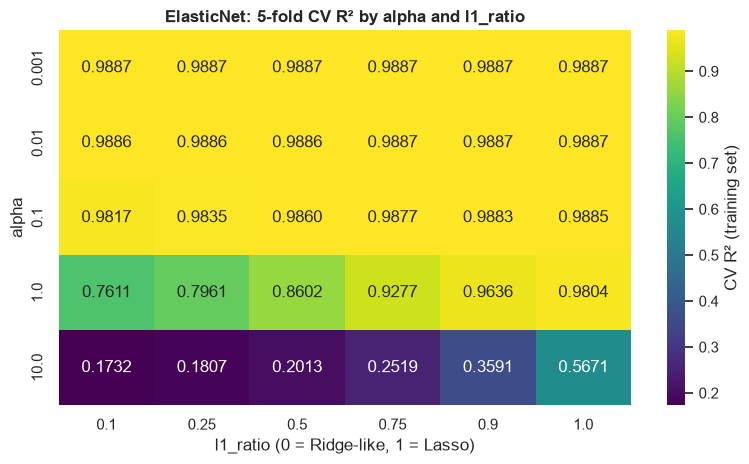

In [45]:
enet_coefs = coefficient_table(enet)
display(enet_coefs.round(4))

enet_grid = GridSearchCV(build_regression_pipeline(ElasticNet(random_state=config.RANDOM_STATE)),
                         {"model__alpha": [0.001, 0.01, 0.1, 1.0, 10.0],
                          "model__l1_ratio": [0.1, 0.25, 0.5, 0.75, 0.9, 1.0]},
                         cv=CV, scoring="r2", n_jobs=-1, refit=False).fit(X_train, y_train)
grid = (pd.DataFrame(enet_grid.cv_results_["params"])
          .assign(cv_r2=enet_grid.cv_results_["mean_test_score"])
          .pivot(index="model__alpha", columns="model__l1_ratio", values="cv_r2"))

fig, ax = plt.subplots(figsize=(8, 4.8))
sns.heatmap(grid, annot=True, fmt=".4f", cmap="viridis", cbar_kws={"label": "CV R² (training set)"}, ax=ax)
ax.set_title("ElasticNet: 5-fold CV R² by alpha and l1_ratio")
ax.set_xlabel("l1_ratio (0 = Ridge-like, 1 = Lasso)")
ax.set_ylabel("alpha")
finalize(fig, "regression_elasticnet_grid")
plt.show()

### Technical Result
*Generated from the computation above; it updates automatically when the notebook is re-run.*

In [46]:
best_a, best_r = np.unravel_index(np.nanargmax(grid.to_numpy()), grid.shape)
technical_result(
    "ElasticNet Regression",
    f"Baseline alpha = 1.0, l1_ratio = 0.5: {int((enet_coefs['coef (per 1 std)'] == 0).sum())} zero coefficient(s).",
    f"Grid CV R² ranges from {np.nanmin(grid.to_numpy()):.4f} to {np.nanmax(grid.to_numpy()):.4f}; "
    f"highest at alpha = {grid.index[best_a]}, l1_ratio = {grid.columns[best_r]}.",
)

- Test set (n = 1,975): **R² = 0.8620**, RMSE = 7.1337, MAE = 5.9257 (Performance Index points).
- Training-set R² = 0.8603 (train − test R² = -0.0017); fit time = 0.013 s.
- Baseline alpha = 1.0, l1_ratio = 0.5: 1 zero coefficient(s).
- Grid CV R² ranges from 0.1732 to 0.9887; highest at alpha = 0.001, l1_ratio = 1.0.

> ### ✍️ TEAM ANALYSIS REQUIRED — `REG-M4-ELASTICNET`: ElasticNet Regression
> **Author:** _(write your name)_
>
> Interpret the output above in your own words (course guideline 7.5: no AI-written analysis).
>
> - How do alpha and l1_ratio each affect cross-validated R² in the grid?
> - Why does the baseline ElasticNet (alpha = 1) score differently from Linear Regression?
> - Is there any advantage in mixing L1 and L2 for this dataset? Explain.
>
> *When done, replace this whole cell with your answer under the heading `### Team analysis — REG-M4-ELASTICNET`.*

## 20.5 Polynomial Regression (PolynomialFeatures + Linear Regression)

**What it is.** Linear Regression applied to an **expanded** set of inputs: all squares, products
(interactions) and higher powers of the original features up to a chosen **degree**.

**How it works.**
1. `PolynomialFeatures(degree=d)` turns the inputs into every term of total degree ≤ d — e.g. with
   degree 2, *x₁, x₂* become *x₁, x₂, x₁², x₁x₂, x₂²*.
2. Ordinary Linear Regression is fitted on those terms, so the model is still linear *in its
   coefficients* but can represent curves and interactions.
3. The number of terms grows quickly with the degree and the number of inputs.

**Why it is evaluated.** It tests whether curvature or interactions add anything over the straight-line
model. Guideline 3.1: "compare degrees".

**Important hyperparameters.** `degree`. Degrees 1, 2 and 3 are compared with **5-fold cross-validation
on the training set**; the degree with the highest mean CV R² is then trained on the full training set
and evaluated once on the test set (the rule is fixed in advance; the test set is not used to choose).

**Scaling.** **Required in practice**: squared and cubed terms of unscaled inputs have very different
magnitudes, which makes the fit numerically poorly conditioned. Expansion here is applied after
standardisation.

**Limitations.** Over-fits easily at high degree; many correlated terms; extrapolates badly outside the
training range.

,number of terms,train R2 (mean),CV R2 (mean),CV R2 (std)
degree,,,,
1,5,0.98871,0.98868,0.00047
2,20,0.98874,0.98866,0.00045
3,55,0.98881,0.98860,0.00048


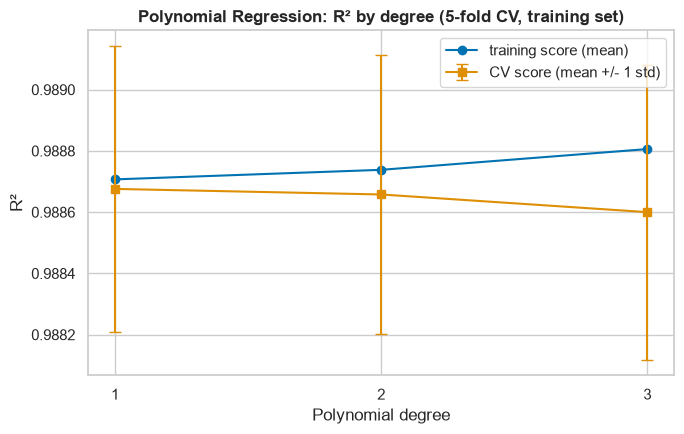

Degree used for the test evaluation (highest mean CV R²): 1


In [47]:
from sklearn.preprocessing import PolynomialFeatures


def polynomial_model(degree):
    """PolynomialFeatures followed by Linear Regression (placed after the shared preprocessing)."""
    return Pipeline([("poly", PolynomialFeatures(degree=degree, include_bias=False)),
                     ("linreg", LinearRegression())])


rows = []
for degree in (1, 2, 3):
    cv_res = cross_validate(build_regression_pipeline(polynomial_model(degree)), X_train, y_train,
                            cv=CV, scoring="r2", return_train_score=True, n_jobs=-1)
    n_inputs = len(PIPELINE_NUMERIC) + len(CATEGORICAL)          # columns after preprocessing (binary -> 1 column)
    n_terms = PolynomialFeatures(degree, include_bias=False).fit(np.zeros((1, n_inputs))).n_output_features_
    rows.append({"degree": degree, "number of terms": n_terms,
                 "train R2 (mean)": cv_res["train_score"].mean(),
                 "CV R2 (mean)": cv_res["test_score"].mean(), "CV R2 (std)": cv_res["test_score"].std()})
poly_degrees = pd.DataFrame(rows).set_index("degree")
display(poly_degrees.round(5))
save_table(poly_degrees, "regression_polynomial_degrees", floatfmt=".5f")

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(poly_degrees.index, poly_degrees["train R2 (mean)"], marker="o", label="training score (mean)")
ax.errorbar(poly_degrees.index, poly_degrees["CV R2 (mean)"], yerr=poly_degrees["CV R2 (std)"],
            marker="s", capsize=4, label="CV score (mean +/- 1 std)")
ax.set_xticks([1, 2, 3])
ax.set_title("Polynomial Regression: R² by degree (5-fold CV, training set)")
ax.set_xlabel("Polynomial degree")
ax.set_ylabel("R²")
ax.legend()
finalize(fig, "regression_polynomial_degrees")
plt.show()

POLY_DEGREE = int(poly_degrees["CV R2 (mean)"].idxmax())     # rule: highest mean CV R² on the training set
print(f"Degree used for the test evaluation (highest mean CV R²): {POLY_DEGREE}")

**Training the chosen degree.** The degree selected by cross-validation above is fitted on the whole training set and evaluated once on the test set.

In [48]:
poly = build_regression_pipeline(polynomial_model(POLY_DEGREE))

t0 = time.perf_counter()
poly.fit(X_train, y_train)
fit_s = time.perf_counter() - t0

poly_pred = poly.predict(X_test)
evaluate("Polynomial Regression", poly, poly_pred, fit_s)

,R2,RMSE,MAE,Train R2,Fit time (s)
Model,,,,,
Polynomial Regression,0.9886,2.0525,1.6416,0.9887,0.013


### Technical Result
*Generated from the computation above; it updates automatically when the notebook is re-run.*

In [49]:
technical_result(
    "Polynomial Regression",
    f"Degree chosen by training-set CV: {POLY_DEGREE} "
    f"({poly.named_steps['model'].named_steps['poly'].n_output_features_} terms).",
    "Mean CV R² by degree: " + ", ".join(f"degree {d} = {v:.5f}" for d, v in poly_degrees["CV R2 (mean)"].items()) + ".",
    f"Largest difference in mean CV R² between degrees: {poly_degrees['CV R2 (mean)'].max() - poly_degrees['CV R2 (mean)'].min():.5f}.",
)

- Test set (n = 1,975): **R² = 0.9886**, RMSE = 2.0525, MAE = 1.6416 (Performance Index points).
- Training-set R² = 0.9887 (train − test R² = +0.0001); fit time = 0.013 s.
- Degree chosen by training-set CV: 1 (5 terms).
- Mean CV R² by degree: degree 1 = 0.98868, degree 2 = 0.98866, degree 3 = 0.98860.
- Largest difference in mean CV R² between degrees: 0.00008.

> ### ✍️ TEAM ANALYSIS REQUIRED — `REG-M5-POLYNOMIAL`: Polynomial Regression
> **Author:** _(write your name)_
>
> Interpret the output above in your own words (course guideline 7.5: no AI-written analysis).
>
> - How large are the differences between degrees 1, 2 and 3 compared with the CV standard deviation? Are they meaningful?
> - What does this say about curvature or interactions in this data?
> - Is the extra complexity of a higher degree justified here?
>
> *When done, replace this whole cell with your answer under the heading `### Team analysis — REG-M5-POLYNOMIAL`.*

## 20.6 Decision Tree Regressor

**What it is.** A tree of yes/no questions about the inputs ("Previous Scores ≤ 72.5?"); each leaf
predicts the **mean target** of the training rows that reach it.

**How it works.**
1. At the root, try every feature and threshold; pick the split that most reduces the squared error.
2. Repeat recursively in each child node.
3. Stop when a node is pure, too small, or `max_depth` is reached.
4. To predict, follow the questions from the root to a leaf and return that leaf's mean.

**Why it is evaluated.** Captures non-linear relationships and interactions automatically, and its
structure is interpretable. Guideline 3.1: "tune max_depth; show feature importance".

**Important hyperparameters.** `max_depth` (default `None` = grow until leaves are pure),
`min_samples_leaf`, `min_samples_split`.

**Scaling.** **Not required** — splits are thresholds, unchanged by rescaling (inputs are scaled here only
because all ten models share one preprocessor).

**Limitations.** Predictions are piecewise constant (a staircase); an unrestricted tree memorises the
training data (over-fitting); small data changes can change the tree a lot.

In [50]:
from sklearn.tree import DecisionTreeRegressor

tree = build_regression_pipeline(DecisionTreeRegressor(random_state=config.RANDOM_STATE))   # max_depth=None (default)

t0 = time.perf_counter()
tree.fit(X_train, y_train)
fit_s = time.perf_counter() - t0

tree_pred = tree.predict(X_test)
evaluate("Decision Tree Regressor", tree, tree_pred, fit_s)

,R2,RMSE,MAE,Train R2,Fit time (s)
Model,,,,,
Decision Tree Regressor,0.9748,3.05,2.4536,0.9993,0.025


**max_depth** (training-set CV curve) and **feature importance** of the baseline tree.

Baseline tree: depth = 20, leaves = 6,518


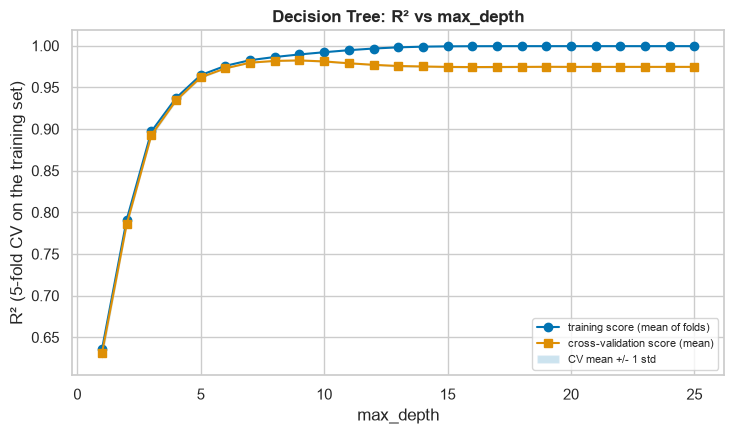

,max_depth,train R2 (mean),CV R2 (mean),CV R2 (std)
0,1,0.6358,0.6310,0.0077
2,3,0.8971,0.8927,0.0025
4,5,0.9647,0.9620,0.0014
6,7,0.9826,0.9796,0.0005
8,9,0.9895,0.9823,0.0007
10,11,0.9946,0.9789,0.0007
14,15,0.9992,0.9745,0.0010
19,20,0.9994,0.9746,0.0008
24,25,0.9994,0.9746,0.0008


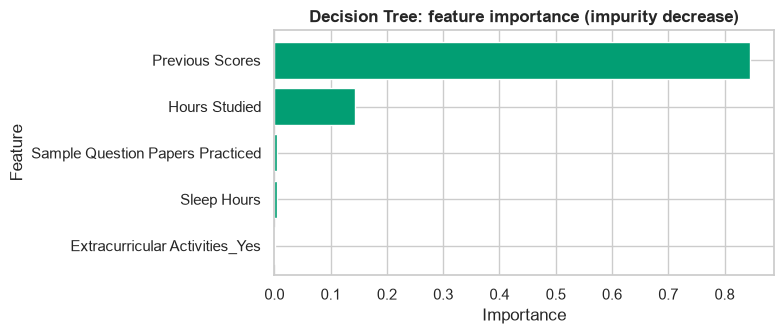

,importance
Previous Scores,0.8456
Hours Studied,0.1429
Sample Question Papers Practiced,0.0053
Sleep Hours,0.0047
Extracurricular Activities_Yes,0.0014


In [51]:
dt_model = tree.named_steps["model"]
print(f"Baseline tree: depth = {dt_model.get_depth()}, leaves = {dt_model.get_n_leaves():,}")

depths = list(range(1, 26))
dt_curve, fig = explore(DecisionTreeRegressor(random_state=config.RANDOM_STATE), "max_depth", depths,
                        "Decision Tree: R² vs max_depth", "max_depth")
finalize(fig, "regression_decision_tree_depth_curve")
plt.show()
display(dt_curve.iloc[[0, 2, 4, 6, 8, 10, 14, 19, 24]])

dt_importance = pd.Series(dt_model.feature_importances_,
                          index=tree.named_steps["preprocess"].get_feature_names_out()).sort_values(ascending=False)
fig = feature_importance(dt_importance.index, dt_importance.values,
                         "Decision Tree: feature importance (impurity decrease)")
finalize(fig, "regression_decision_tree_feature_importance")
plt.show()
dt_importance.round(4).rename("importance").to_frame()

### Technical Result
*Generated from the computation above; it updates automatically when the notebook is re-run.*

In [52]:
best = dt_curve.loc[dt_curve["CV R2 (mean)"].idxmax()]
technical_result(
    "Decision Tree Regressor",
    f"Baseline (max_depth=None) grew to depth {dt_model.get_depth()} with {dt_model.get_n_leaves():,} leaves.",
    f"Training-set CV R² is highest at max_depth = {best['max_depth']} ({best['CV R2 (mean)']:.4f}); "
    f"at max_depth = 25 it is {dt_curve['CV R2 (mean)'].iloc[-1]:.4f}.",
    "Feature importance: " + "; ".join(f"{k} = {v:.4f}" for k, v in dt_importance.items()) + ".",
)

- Test set (n = 1,975): **R² = 0.9748**, RMSE = 3.0500, MAE = 2.4536 (Performance Index points).
- Training-set R² = 0.9993 (train − test R² = +0.0245); fit time = 0.025 s.
- Baseline (max_depth=None) grew to depth 20 with 6,518 leaves.
- Training-set CV R² is highest at max_depth = 9 (0.9823); at max_depth = 25 it is 0.9746.
- Feature importance: Previous Scores = 0.8456; Hours Studied = 0.1429; Sample Question Papers Practiced = 0.0053; Sleep Hours = 0.0047; Extracurricular Activities_Yes = 0.0014.

> ### ✍️ TEAM ANALYSIS REQUIRED — `REG-M6-TREE`: Decision Tree Regressor
> **Author:** _(write your name)_
>
> Interpret the output above in your own words (course guideline 7.5: no AI-written analysis).
>
> - Compare training and test R² for the unrestricted tree. What does the depth curve show about over-fitting?
> - Does the feature-importance ranking agree with the linear coefficients and the correlation heatmap?
> - Why might a tree (a step function) be at a disadvantage on this target?
>
> *When done, replace this whole cell with your answer under the heading `### Team analysis — REG-M6-TREE`.*

## 20.7 Random Forest Regressor

**What it is.** An **ensemble** of many decision trees whose predictions are averaged.

**How it works.**
1. Draw a bootstrap sample (sampling rows with replacement) of the training set for each tree.
2. Grow a deep tree on it; at each split only a random subset of features may be considered
   (for regression scikit-learn's default considers all features, so the randomness comes from bootstrapping).
3. Repeat for `n_estimators` trees.
4. Predict by averaging all trees' predictions — averaging many noisy, de-correlated trees reduces variance.

**Why it is evaluated.** The standard ensemble baseline: usually far more stable and accurate than a
single tree. Guideline 3.1: "Ensemble baseline; tune n_estimators".

**Important hyperparameters.** `n_estimators` (default 100), `max_depth`, `max_features`, `min_samples_leaf`.

**Scaling.** **Not required** (tree-based).

**Limitations.** Slower and much larger than one tree; less interpretable; like any tree model it cannot
predict outside the range of targets seen in training; importances are biased towards features with many
distinct values.

In [53]:
from sklearn.ensemble import RandomForestRegressor

# n_jobs=1: with several threads the per-tree predictions are summed in a varying order, which changes
# the result in the ~14th decimal place between calls. Single-threaded prediction is bit-for-bit reproducible.
forest = build_regression_pipeline(
    RandomForestRegressor(n_estimators=100, random_state=config.RANDOM_STATE, n_jobs=1))   # default n_estimators

t0 = time.perf_counter()
forest.fit(X_train, y_train)
fit_s = time.perf_counter() - t0

forest_pred = forest.predict(X_test)
evaluate("Random Forest Regressor", forest, forest_pred, fit_s)

,R2,RMSE,MAE,Train R2,Fit time (s)
Model,,,,,
Random Forest Regressor,0.9847,2.3737,1.9153,0.9975,0.885


**n_estimators** (training-set CV curve) and **feature importance** *(rubric C4: tree-based feature importance)*.

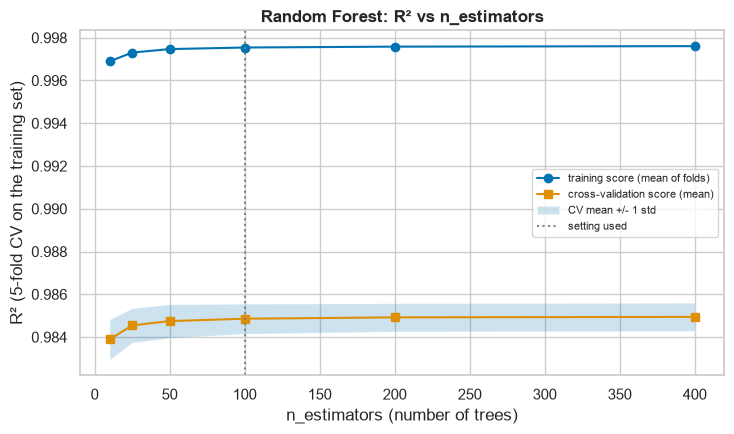

,n_estimators,train R2 (mean),CV R2 (mean),CV R2 (std)
0,10,0.9969,0.9839,0.0009
1,25,0.9973,0.9845,0.0008
2,50,0.9975,0.9847,0.0008
3,100,0.9975,0.9849,0.0007
4,200,0.9976,0.9849,0.0007
5,400,0.9976,0.9849,0.0007


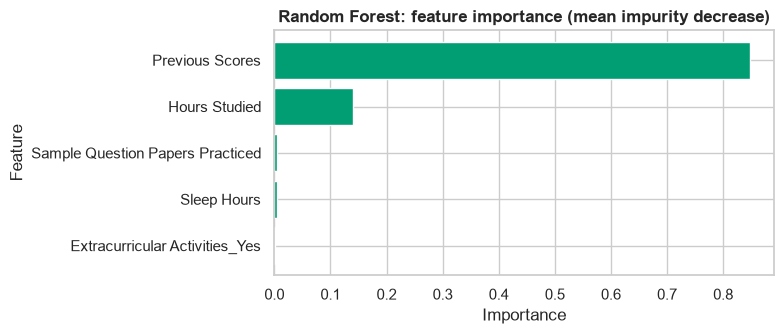

,importance
Previous Scores,0.8482
Hours Studied,0.1405
Sample Question Papers Practiced,0.0052
Sleep Hours,0.0047
Extracurricular Activities_Yes,0.0013


In [54]:
n_trees = [10, 25, 50, 100, 200, 400]
rf_curve, fig = explore(RandomForestRegressor(random_state=config.RANDOM_STATE, n_jobs=1), "n_estimators", n_trees,
                        "Random Forest: R² vs n_estimators", "n_estimators (number of trees)", marker_value=100)
finalize(fig, "regression_random_forest_n_estimators_curve")
plt.show()
display(rf_curve)

rf_importance = pd.Series(forest.named_steps["model"].feature_importances_,
                          index=forest.named_steps["preprocess"].get_feature_names_out()).sort_values(ascending=False)
fig = feature_importance(rf_importance.index, rf_importance.values,
                         "Random Forest: feature importance (mean impurity decrease)")
finalize(fig, "regression_random_forest_feature_importance")
plt.show()
rf_importance.round(4).rename("importance").to_frame()

### Technical Result
*Generated from the computation above; it updates automatically when the notebook is re-run.*

In [55]:
technical_result(
    "Random Forest Regressor",
    "Training-set CV R² by n_estimators: " + ", ".join(f"{n} = {v:.4f}" for n, v in zip(n_trees, rf_curve["CV R2 (mean)"])) + ".",
    "Feature importance: " + "; ".join(f"{k} = {v:.4f}" for k, v in rf_importance.items()) + ".",
)

- Test set (n = 1,975): **R² = 0.9847**, RMSE = 2.3737, MAE = 1.9153 (Performance Index points).
- Training-set R² = 0.9975 (train − test R² = +0.0127); fit time = 0.885 s.
- Training-set CV R² by n_estimators: 10 = 0.9839, 25 = 0.9845, 50 = 0.9847, 100 = 0.9849, 200 = 0.9849, 400 = 0.9849.
- Feature importance: Previous Scores = 0.8482; Hours Studied = 0.1405; Sample Question Papers Practiced = 0.0052; Sleep Hours = 0.0047; Extracurricular Activities_Yes = 0.0013.

> ### ✍️ TEAM ANALYSIS REQUIRED — `REG-M7-FOREST`: Random Forest Regressor
> **Author:** _(write your name)_
>
> Interpret the output above in your own words (course guideline 7.5: no AI-written analysis).
>
> - How does performance change as n_estimators grows? Where does adding trees stop helping?
> - How do the Random Forest's results and train–test gap compare with the single Decision Tree? Why?
> - Do the importances agree with the Decision Tree and the linear coefficients?
>
> *When done, replace this whole cell with your answer under the heading `### Team analysis — REG-M7-FOREST`.*

## 20.8 Gradient Boosting Regressor

**What it is.** An ensemble of **shallow** trees built **sequentially**, each one correcting the errors
of the trees before it (scikit-learn's `GradientBoostingRegressor`).

**How it works.**
1. Start with a constant prediction (the mean of *y*).
2. Compute the residuals (the negative gradient of the squared-error loss).
3. Fit a small tree (default depth 3) to those residuals.
4. Add that tree's predictions, multiplied by the `learning_rate`, to the current model.
5. Repeat for `n_estimators` rounds.

**Why it is evaluated.** Boosting is often the strongest method on tabular data. Guideline 3.1:
"sklearn GBM or XGBoost; tune learning_rate".

**Important hyperparameters.** `learning_rate` (default 0.1) — how much each tree contributes;
`n_estimators` (default 100); `max_depth` (default 3). A smaller learning rate usually needs more trees.

**Scaling.** **Not required** (tree-based).

**Limitations.** Sequential, so slower to train than a forest of the same size; more hyperparameters
that interact; can over-fit with too many rounds or too large a learning rate.

In [56]:
from sklearn.ensemble import GradientBoostingRegressor

gboost = build_regression_pipeline(GradientBoostingRegressor(random_state=config.RANDOM_STATE))   # lr=0.1, 100 trees, depth 3

t0 = time.perf_counter()
gboost.fit(X_train, y_train)
fit_s = time.perf_counter() - t0

gboost_pred = gboost.predict(X_test)
evaluate("Gradient Boosting Regressor", gboost, gboost_pred, fit_s)

,R2,RMSE,MAE,Train R2,Fit time (s)
Model,,,,,
Gradient Boosting Regressor,0.988,2.1075,1.6839,0.9888,0.263


**learning_rate** (training-set CV curve, with `n_estimators` fixed at the default 100).

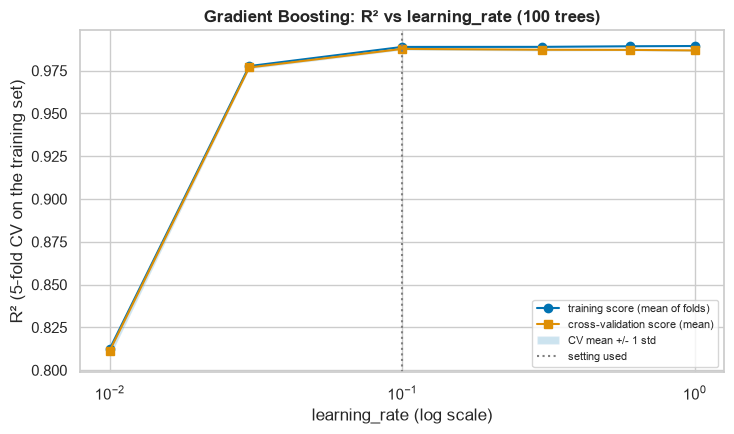

,learning_rate,train R2 (mean),CV R2 (mean),CV R2 (std)
0,0.01,0.8123,0.8113,0.0035
1,0.03,0.9777,0.9769,0.0008
2,0.1,0.9889,0.9877,0.0007
3,0.3,0.9889,0.9872,0.0007
4,0.6,0.9893,0.9872,0.0005
5,1.0,0.9894,0.9869,0.0006


In [57]:
learning_rates = [0.01, 0.03, 0.1, 0.3, 0.6, 1.0]
gb_curve, fig = explore(GradientBoostingRegressor(random_state=config.RANDOM_STATE), "learning_rate", learning_rates,
                        "Gradient Boosting: R² vs learning_rate (100 trees)", "learning_rate (log scale)",
                        log_x=True, marker_value=0.1)
finalize(fig, "regression_gradient_boosting_learning_rate_curve")
plt.show()
gb_curve

### Technical Result
*Generated from the computation above; it updates automatically when the notebook is re-run.*

In [58]:
best = gb_curve.loc[gb_curve["CV R2 (mean)"].idxmax()]
technical_result(
    "Gradient Boosting Regressor",
    "Training-set CV R² by learning_rate (100 trees): "
    + ", ".join(f"{lr} = {v:.4f}" for lr, v in zip(learning_rates, gb_curve["CV R2 (mean)"])) + ".",
    f"Highest CV R² at learning_rate = {best['learning_rate']}.",
)

- Test set (n = 1,975): **R² = 0.9880**, RMSE = 2.1075, MAE = 1.6839 (Performance Index points).
- Training-set R² = 0.9888 (train − test R² = +0.0008); fit time = 0.263 s.
- Training-set CV R² by learning_rate (100 trees): 0.01 = 0.8113, 0.03 = 0.9769, 0.1 = 0.9877, 0.3 = 0.9872, 0.6 = 0.9872, 1.0 = 0.9869.
- Highest CV R² at learning_rate = 0.1.

> ### ✍️ TEAM ANALYSIS REQUIRED — `REG-M8-BOOSTING`: Gradient Boosting Regressor
> **Author:** _(write your name)_
>
> Interpret the output above in your own words (course guideline 7.5: no AI-written analysis).
>
> - What happens to CV R² at very small and very large learning rates? Why, given how boosting works?
> - How does Gradient Boosting compare with Random Forest here, and with the linear models?
>
> *When done, replace this whole cell with your answer under the heading `### Team analysis — REG-M8-BOOSTING`.*

## 20.9 Support Vector Regressor (SVR)

**What it is.** A regression model that fits a function lying within a tube of width ±ε around the
training targets, as "flat" as possible, and only penalises points outside the tube.

**How it works.**
1. Errors smaller than `epsilon` are ignored (the ε-insensitive loss).
2. Points outside the tube are penalised linearly, weighted by `C`.
3. The solution depends only on the points on or outside the tube — the **support vectors**.
4. A **kernel** lets the function be non-linear: `linear`, `poly` (polynomial), or `rbf` (Gaussian,
   similarity decays with distance at a rate set by `gamma`).

**Why it is evaluated.** A different principle from least squares (robust ε-insensitive loss, kernels).
Guideline 3.1: "Scale features first; tune C and kernel".

**Important hyperparameters.**
* `C` (default 1.0) — penalty for points outside the tube; larger C fits the training data more closely.
* `kernel` (default `rbf`).
* `gamma` (for `rbf`/`poly`; default `"scale"` = 1 / (n_features × variance of X)) — how far one
  training point's influence reaches; large gamma = very local, wiggly function.
* `epsilon` (default 0.1, in target units) — tube width.

**Scaling.** Generally recommended for SVR: kernels are built on distances or dot products, so an input
with a large range (Previous Scores: 40–99) carries more weight than one with a small range (Sleep Hours:
4–9). The actual effect on this data is **measured** below (with vs. without `StandardScaler`).

**Limitations.** Training time grows roughly quadratically or worse with the number of rows; several
interacting hyperparameters; no direct feature importances for non-linear kernels.

In [59]:
from sklearn.svm import SVR

svr = build_regression_pipeline(SVR())      # defaults: kernel="rbf", C=1.0, epsilon=0.1, gamma="scale"

t0 = time.perf_counter()
svr.fit(X_train, y_train)
fit_s = time.perf_counter() - t0

svr_pred = svr.predict(X_test)
evaluate("Support Vector Regressor", svr, svr_pred, fit_s)

,R2,RMSE,MAE,Train R2,Fit time (s)
Model,,,,,
Support Vector Regressor,0.986,2.2755,1.7953,0.9862,1.208


**Scaling, kernel × C, and gamma.** All three use 5-fold CV on the training set only. For the scaling
comparison, the identical default SVR is run with and without `StandardScaler`.

Support vectors in the baseline SVR: 7,597 of 7,898 training rows
gamma="scale" evaluates to 0.2249 for this training matrix


,CV R2 (mean),CV R2 (std),mean fit time (s)
with StandardScaler,0.9849,0.0001,1.0876
without scaling,0.9838,0.0006,1.0830


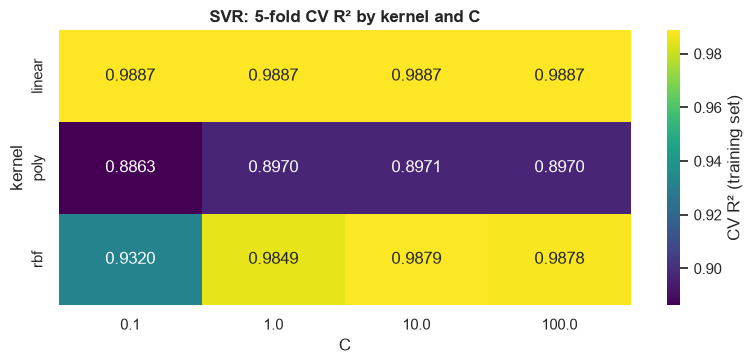

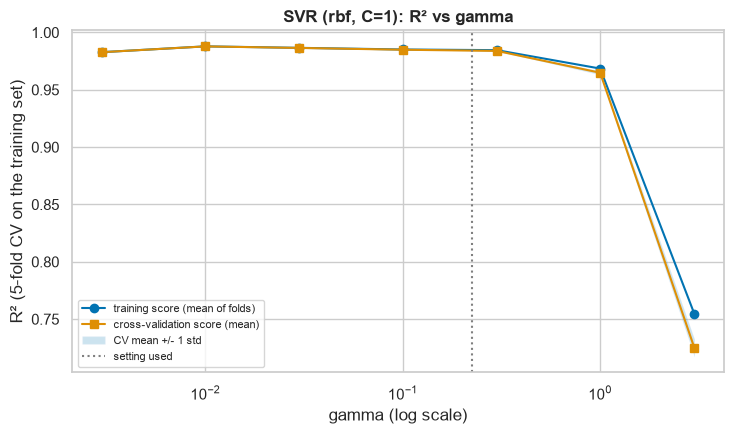

,gamma,train R2 (mean),CV R2 (mean),CV R2 (std)
0,0.003,0.9828,0.9828,0.0004
1,0.01,0.9879,0.9878,0.0003
2,0.03,0.9866,0.9865,0.0002
3,0.1,0.9851,0.9849,0.0001
4,0.3,0.9846,0.9839,0.0002
5,1.0,0.9685,0.9649,0.0017
6,3.0,0.7545,0.7249,0.0078


In [60]:
# gamma="scale" is computed from the (preprocessed) training matrix:
Z = svr.named_steps["preprocess"].transform(svr.named_steps["add_features"].transform(X_train))
gamma_scale = 1.0 / (Z.shape[1] * Z.var())
print(f"Support vectors in the baseline SVR: {len(svr.named_steps['model'].support_):,} of {len(X_train):,} training rows")
print(f'gamma="scale" evaluates to {gamma_scale:.4f} for this training matrix')

# 1) Scaling on vs off (same default SVR)
scaling = {}
for label, scale in [("with StandardScaler", True), ("without scaling", False)]:
    s = cross_validate(build_regression_pipeline(SVR(), scale=scale), X_train, y_train, cv=CV, scoring="r2", n_jobs=-1)
    scaling[label] = {"CV R2 (mean)": s["test_score"].mean(), "CV R2 (std)": s["test_score"].std(),
                      "mean fit time (s)": s["fit_time"].mean()}
svr_scaling = pd.DataFrame(scaling).T.round(4)
display(svr_scaling)

# 2) kernel x C
svr_grid = GridSearchCV(build_regression_pipeline(SVR()),
                        {"model__kernel": ["linear", "poly", "rbf"], "model__C": [0.1, 1.0, 10.0, 100.0]},
                        cv=CV, scoring="r2", n_jobs=-1, refit=False).fit(X_train, y_train)
kc = (pd.DataFrame(svr_grid.cv_results_["params"])
        .assign(cv_r2=svr_grid.cv_results_["mean_test_score"])
        .pivot(index="model__kernel", columns="model__C", values="cv_r2"))
fig, ax = plt.subplots(figsize=(8, 3.8))
sns.heatmap(kc, annot=True, fmt=".4f", cmap="viridis", cbar_kws={"label": "CV R² (training set)"}, ax=ax)
ax.set_title("SVR: 5-fold CV R² by kernel and C")
ax.set_xlabel("C")
ax.set_ylabel("kernel")
finalize(fig, "regression_svr_kernel_C_grid")
plt.show()

# 3) gamma for the rbf kernel (C = 1)
gammas = [0.003, 0.01, 0.03, 0.1, 0.3, 1.0, 3.0]
svr_gamma, fig = explore(SVR(kernel="rbf"), "gamma", gammas, "SVR (rbf, C=1): R² vs gamma",
                         "gamma (log scale)", log_x=True, marker_value=gamma_scale)
finalize(fig, "regression_svr_gamma_curve")
plt.show()
svr_gamma

### Technical Result
*Generated from the computation above; it updates automatically when the notebook is re-run.*

In [61]:
best_k, best_c = np.unravel_index(np.nanargmax(kc.to_numpy()), kc.shape)
technical_result(
    "Support Vector Regressor",
    f"Baseline (rbf, C=1, epsilon=0.1, gamma=scale={gamma_scale:.4f}) uses "
    f"{len(svr.named_steps['model'].support_):,} support vectors.",
    f"Default SVR CV R²: with scaling {svr_scaling.loc['with StandardScaler', 'CV R2 (mean)']:.4f}, "
    f"without scaling {svr_scaling.loc['without scaling', 'CV R2 (mean)']:.4f}.",
    f"kernel × C grid: CV R² from {np.nanmin(kc.to_numpy()):.4f} to {np.nanmax(kc.to_numpy()):.4f}; "
    f"highest for kernel = {kc.index[best_k]}, C = {kc.columns[best_c]}.",
    f"rbf gamma curve: CV R² from {svr_gamma['CV R2 (mean)'].min():.4f} to {svr_gamma['CV R2 (mean)'].max():.4f}.",
)

- Test set (n = 1,975): **R² = 0.9860**, RMSE = 2.2755, MAE = 1.7953 (Performance Index points).
- Training-set R² = 0.9862 (train − test R² = +0.0002); fit time = 1.208 s.
- Baseline (rbf, C=1, epsilon=0.1, gamma=scale=0.2249) uses 7,597 support vectors.
- Default SVR CV R²: with scaling 0.9849, without scaling 0.9838.
- kernel × C grid: CV R² from 0.8863 to 0.9887; highest for kernel = linear, C = 10.0.
- rbf gamma curve: CV R² from 0.7249 to 0.9878.

> ### ✍️ TEAM ANALYSIS REQUIRED — `REG-M9-SVR`: Support Vector Regressor
> **Author:** _(write your name)_
>
> Interpret the output above in your own words (course guideline 7.5: no AI-written analysis).
>
> - What does the scaling comparison show, and why does SVR depend on scaling?
> - Which kernel and C work best in the grid, and what does that suggest about the shape of the relationship?
> - What happens at very large gamma, and why?
>
> *When done, replace this whole cell with your answer under the heading `### Team analysis — REG-M9-SVR`.*

## 20.10 K-Nearest Neighbors Regressor

**What it is.** A "lazy" model: it stores the training rows and predicts the **average target of the k
most similar training rows**.

**How it works.**
1. "Training" only stores the (preprocessed) training data.
2. For a new row, compute its distance to every training row — by default the Euclidean distance
   √Σ(aⱼ − bⱼ)² (Minkowski with p = 2).
3. Take the k closest rows.
4. Predict their mean target (`weights="uniform"`) or a distance-weighted mean (`weights="distance"`).

**Why it is evaluated.** A non-parametric model with no assumed functional form. Guideline 3.1:
"Tune k; discuss impact of scaling".

**Important hyperparameters.** `n_neighbors` = k (default 5): small k → low bias, high variance; large
k → smoother, more biased. `weights`, and the distance `metric` (`p=2` Euclidean, `p=1` Manhattan,
Chebyshev = largest single difference).

**Scaling.** Distances add up differences across features, so without standardisation a feature measured
on a large range (Previous Scores, range 59) carries far more weight in the distance than one on a small
range (Sleep Hours, range 5); standardisation gives every feature equal weight. Whether equal weighting
helps depends on how informative each feature is — the actual effect on this data is **measured** below.

**Limitations.** Prediction is slow for large data (distances to every training row); suffers in
high-dimensional spaces; cannot extrapolate beyond the training targets; ties between equidistant
neighbours can be broken differently on different machines (a known small reproducibility caveat).

In [62]:
from sklearn.neighbors import KNeighborsRegressor

knn = build_regression_pipeline(KNeighborsRegressor())   # defaults: k=5, weights="uniform", Euclidean distance

t0 = time.perf_counter()
knn.fit(X_train, y_train)
fit_s = time.perf_counter() - t0

knn_pred = knn.predict(X_test)
evaluate("K-Nearest Neighbors Regressor", knn, knn_pred, fit_s)

,R2,RMSE,MAE,Train R2,Fit time (s)
Model,,,,,
K-Nearest Neighbors Regressor,0.976,2.9736,2.3687,0.9839,0.015


**k, scaling and distance metric.** The k curve is computed twice — with and without standardisation —
and the distance metrics are compared at k = 5 (all 5-fold CV on the training set).

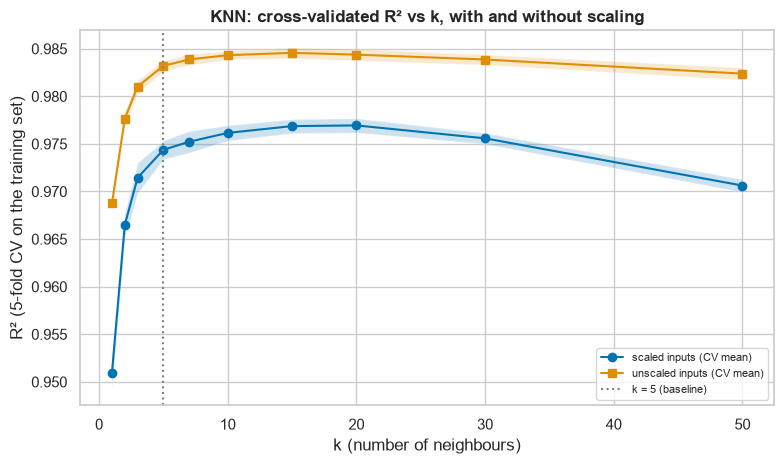

,k,CV R2 scaled (mean),CV R2 unscaled (mean)
0,1,0.9509,0.9687
1,2,0.9665,0.9777
2,3,0.9715,0.9810
3,5,0.9744,0.9832
4,7,0.9752,0.9839
5,10,0.9762,0.9843
6,15,0.9769,0.9846
7,20,0.9769,0.9844
8,30,0.9756,0.9839
9,50,0.9706,0.9824


weights (k = 5),distance,uniform
distance metric,,
chebyshev,0.9738,0.9720
euclidean,0.9756,0.9744
manhattan,0.9736,0.9712


In [63]:
ks = [1, 2, 3, 5, 7, 10, 15, 20, 30, 50]
curves = {}
for label, scale in [("scaled", True), ("unscaled", False)]:
    _, cv_sc = validation_curve(build_regression_pipeline(KNeighborsRegressor(), scale=scale), X_train, y_train,
                                param_name="model__n_neighbors", param_range=ks, cv=CV, scoring="r2", n_jobs=-1)
    curves[label] = cv_sc
knn_k = pd.DataFrame({"k": ks,
                      "CV R2 scaled (mean)": curves["scaled"].mean(axis=1),
                      "CV R2 unscaled (mean)": curves["unscaled"].mean(axis=1)}).round(4)

fig, ax = plt.subplots(figsize=(8, 4.8))
for label, marker in [("scaled", "o"), ("unscaled", "s")]:
    m, s = curves[label].mean(axis=1), curves[label].std(axis=1)
    ax.plot(ks, m, marker=marker, label=f"{label} inputs (CV mean)")
    ax.fill_between(ks, m - s, m + s, alpha=0.2)
ax.axvline(5, color="grey", linestyle=":", label="k = 5 (baseline)")
ax.set_title("KNN: cross-validated R² vs k, with and without scaling")
ax.set_xlabel("k (number of neighbours)")
ax.set_ylabel("R² (5-fold CV on the training set)")
ax.legend(fontsize=8)
finalize(fig, "regression_knn_k_and_scaling")
plt.show()
display(knn_k)

knn_metric_grid = GridSearchCV(build_regression_pipeline(KNeighborsRegressor()),
                               {"model__metric": ["euclidean", "manhattan", "chebyshev"],
                                "model__weights": ["uniform", "distance"]},
                               cv=CV, scoring="r2", n_jobs=-1, refit=False).fit(X_train, y_train)
knn_metrics = (pd.DataFrame(knn_metric_grid.cv_results_["params"])
                 .assign(cv_r2=knn_metric_grid.cv_results_["mean_test_score"])
                 .pivot(index="model__metric", columns="model__weights", values="cv_r2").round(4))
knn_metrics.index.name, knn_metrics.columns.name = "distance metric", "weights (k = 5)"
knn_metrics

### Technical Result
*Generated from the computation above; it updates automatically when the notebook is re-run.*

In [64]:
best_row = knn_k.loc[knn_k["CV R2 scaled (mean)"].idxmax()]
technical_result(
    "K-Nearest Neighbors Regressor",
    f"Scaled inputs: CV R² highest at k = {int(best_row['k'])} ({best_row['CV R2 scaled (mean)']:.4f}); "
    f"at k = 1 it is {knn_k['CV R2 scaled (mean)'].iloc[0]:.4f}.",
    f"At k = 5: CV R² scaled = {knn_k.set_index('k').loc[5, 'CV R2 scaled (mean)']:.4f}, "
    f"unscaled = {knn_k.set_index('k').loc[5, 'CV R2 unscaled (mean)']:.4f}.",
    "Distance metrics at k = 5 (uniform weights): "
    + ", ".join(f"{m} = {v:.4f}" for m, v in knn_metrics["uniform"].items()) + ".",
)

- Test set (n = 1,975): **R² = 0.9760**, RMSE = 2.9736, MAE = 2.3687 (Performance Index points).
- Training-set R² = 0.9839 (train − test R² = +0.0079); fit time = 0.015 s.
- Scaled inputs: CV R² highest at k = 15 (0.9769); at k = 1 it is 0.9509.
- At k = 5: CV R² scaled = 0.9744, unscaled = 0.9832.
- Distance metrics at k = 5 (uniform weights): chebyshev = 0.9720, euclidean = 0.9744, manhattan = 0.9712.

> ### ✍️ TEAM ANALYSIS REQUIRED — `REG-M10-KNN`: K-Nearest Neighbors Regressor
> **Author:** _(write your name)_
>
> Interpret the output above in your own words (course guideline 7.5: no AI-written analysis).
>
> - How does k trade off bias and variance in the curve? What happens at k = 1?
> - Explain the scaled vs unscaled difference using the ranges of the input features.
> - Which distance metric and weighting work best, and why might that be for these inputs?
>
> *When done, replace this whole cell with your answer under the heading `### Team analysis — REG-M10-KNN`.*

## 20.11 Consolidated comparison of all ten models  *(rubric C2)*

**What:** one table with R², RMSE and MAE for all ten models on the **same** held-out test set, ranked by
R² (highest first). A second table adds the training R², the train–test gap and the fit time.

**Why:** guideline 7.2 requires results in a single summary table rather than scattered print statements.
The table is built from the `results` dictionary filled by `evaluate(...)` in each section, and the cell
below independently re-computes every metric from the stored fitted pipelines to confirm that the table
and the per-model outputs agree.

This table reports baseline (default-hyperparameter) models. **No final model is selected here.**

In [65]:
from src.regression_models import REGRESSION_ALGORITHM_NAMES

comparison = (pd.DataFrame.from_dict(results, orient="index")
                [["R2", "RMSE", "MAE"]]
                .rename(columns={"R2": "R²"})
                .sort_values("R²", ascending=False))
comparison.index.name = "Model"
comparison.insert(0, "Rank (by R²)", range(1, len(comparison) + 1))
save_table(comparison, "regression_comparison")
comparison.round(4)

,Rank (by R²),R²,RMSE,MAE
Model,,,,
Ridge Regression,1,0.9886,2.0524,1.6415
Linear Regression,2,0.9886,2.0525,1.6416
Polynomial Regression,3,0.9886,2.0525,1.6416
Gradient Boosting Regressor,4,0.9880,2.1075,1.6839
Support Vector Regressor,5,0.9860,2.2755,1.7953
Random Forest Regressor,6,0.9847,2.3737,1.9153
Lasso Regression,7,0.9806,2.6760,2.1457
K-Nearest Neighbors Regressor,8,0.9760,2.9736,2.3687
Decision Tree Regressor,9,0.9748,3.0500,2.4536


**Supporting details.** Training R², the train–test gap and fit time for each model, and a bar chart of test R² (axis starts at 0 so that small differences are not visually exaggerated).

,R2,Train R2,Train R2 - Test R2,Fit time (s)
Model,,,,
Ridge Regression,0.9886,0.9887,0.0001,0.010
Linear Regression,0.9886,0.9887,0.0001,0.010
Polynomial Regression,0.9886,0.9887,0.0001,0.013
Gradient Boosting Regressor,0.9880,0.9888,0.0008,0.263
Support Vector Regressor,0.9860,0.9862,0.0002,1.208
Random Forest Regressor,0.9847,0.9975,0.0127,0.885
Lasso Regression,0.9806,0.9804,-0.0002,0.014
K-Nearest Neighbors Regressor,0.9760,0.9839,0.0079,0.015
Decision Tree Regressor,0.9748,0.9993,0.0245,0.025


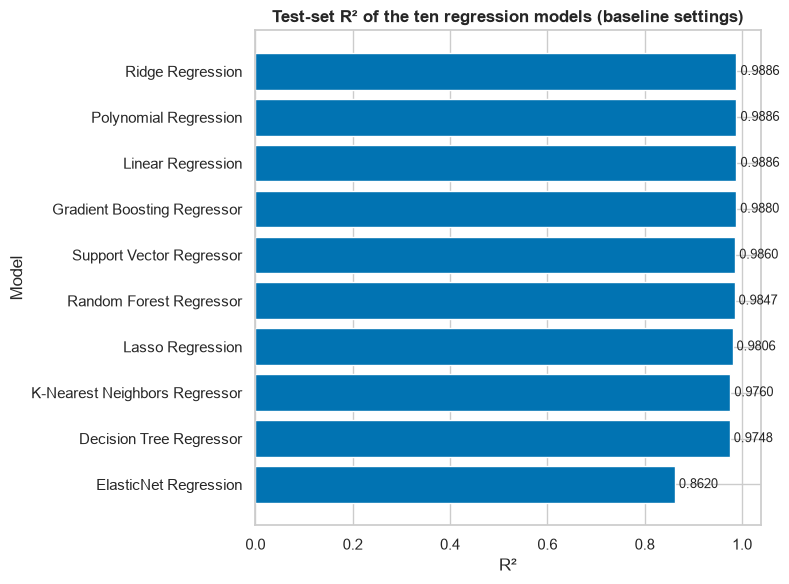

In [66]:
details = pd.DataFrame.from_dict(results, orient="index").loc[comparison.index]
details["Train R2 - Test R2"] = details["Train R2"] - details["R2"]
details = details[["R2", "Train R2", "Train R2 - Test R2", "Fit time (s)"]]
save_table(details, "regression_comparison_details")
display(details.round(4))

from src.plotting import bar_comparison
fig = bar_comparison(comparison, "R²", "Test-set R² of the ten regression models (baseline settings)")
finalize(fig, "regression_comparison_r2")
plt.show()

**Consistency check** — do the table and the models agree?

In [67]:
assert sorted(comparison.index) == sorted(REGRESSION_ALGORITHM_NAMES), "the table must contain exactly the ten required models"
max_diff = 0.0
for name, pipe in fitted.items():
    recomputed = regression_metrics(y_test, pipe.predict(X_test))       # fresh predictions on the same test set
    for metric, col in [("R2", "R²"), ("RMSE", "RMSE"), ("MAE", "MAE")]:
        max_diff = max(max_diff, abs(recomputed[metric] - comparison.loc[name, col]))
assert max_diff < 1e-12, f"table and models disagree (max difference {max_diff})"
print(f"All 10 models present; every table value re-computed from the fitted pipelines "
      f"(largest difference {max_diff:.1e}).")
print(f"Every model was evaluated on the same {len(X_test):,} test rows and trained on the same {len(X_train):,} training rows.")

All 10 models present; every table value re-computed from the fitted pipelines (largest difference 0.0e+00).
Every model was evaluated on the same 1,975 test rows and trained on the same 7,898 training rows.


## 20.12 Effect of the engineered feature  *(rubric B3)*

Once the team registers a feature (section 19), this cell refits every model **without** it and reports
the change in test metrics. With nothing registered it only says so.

In [68]:
if not ENGINEERED:
    print("No engineered feature is registered yet (section 19) - nothing to compare.")
else:
    rows = []
    for name, pipe in fitted.items():
        without = build_regression_pipeline(clone(pipe.named_steps["model"]), engineered=False).fit(X_train, y_train)
        m_without = regression_metrics(y_test, without.predict(X_test))
        rows.append({"Model": name, "R² without": m_without["R2"], "R² with": results[name]["R2"],
                     "RMSE without": m_without["RMSE"], "RMSE with": results[name]["RMSE"]})
    fe_effect = pd.DataFrame(rows).set_index("Model")
    fe_effect["R² change"] = fe_effect["R² with"] - fe_effect["R² without"]
    save_table(fe_effect, "regression_engineered_feature_effect")
    display(fe_effect.round(4))

No engineered feature is registered yet (section 19) - nothing to compare.


## 21. Cross-validation, tuning, diagnostics and saved models  *(guidelines 3.1, 7.2; rubric C3, C4)*

Two different kinds of numbers appear from here on, and they must not be mixed up:

| Kind | Computed on | Used for |
|---|---|---|
| **TRAINING-SIDE CROSS-VALIDATION** results | the 7,898 training rows only, split into 5 folds | choosing which models to tune, and which hyperparameters |
| **HELD-OUT TEST-SET** results | the 1,975 test rows, never seen during training, CV or tuning | reporting how the chosen settings perform on unseen data |

A tuned **CV** score is never compared with an untuned **test** score as if they were the same quantity:
CV is compared with CV, and test with test.

## 21.1 Training-side 5-fold cross-validation of all ten baseline models

**What:** 5-fold cross-validation of every baseline model on the **training set only**, reporting the
mean and standard deviation of R² (plus RMSE and MAE) and the individual fold scores.

**Why:** a single test split gives one number per model that depends on which rows happened to fall in
the test set. Cross-validation measures each model five times on different partitions of the training
data, giving a mean *and* a spread. Because it never touches the test set, it can legitimately be used
to decide which models go forward to tuning — the test table in 20.11 must **not** be used for that.

**Concept — no leakage inside CV:** each fold refits the *whole pipeline* (engineered features →
imputer → encoder → scaler → model) on the four training folds and scores it on the fifth, so no
statistic from the scoring fold leaks into preprocessing. The splitter `CV` is the same seeded
`KFold(5, shuffle=True, random_state=42)` used throughout section 20.

In [69]:
CV_SCORING = {"r2": "r2", "rmse": "neg_root_mean_squared_error", "mae": "neg_mean_absolute_error"}
cv_summary, fold_scores = {}, {}
for name, pipe in fitted.items():
    baseline = build_regression_pipeline(clone(pipe.named_steps["model"]))   # fresh, unfitted copy of the baseline
    res = cross_validate(baseline, X_train, y_train, cv=CV, scoring=CV_SCORING, n_jobs=5)   # TRAINING data only
    fold_scores[name] = res["test_r2"]
    cv_summary[name] = {"CV R² (mean)": res["test_r2"].mean(), "CV R² (std)": res["test_r2"].std(),
                        "CV RMSE (mean)": -res["test_rmse"].mean(), "CV MAE (mean)": -res["test_mae"].mean()}

cv_table = pd.DataFrame.from_dict(cv_summary, orient="index").sort_values("CV R² (mean)", ascending=False)
cv_table.index.name = "Model"
cv_table.insert(0, "CV rank", range(1, len(cv_table) + 1))
save_table(cv_table, "regression_cv_all_models", floatfmt=".6f")
print("TRAINING-SIDE 5-FOLD CROSS-VALIDATION (no test data involved)")
display(cv_table.round(6))

folds = pd.DataFrame(fold_scores, index=[f"fold {k}" for k in range(1, config.CV_FOLDS + 1)]).T.loc[cv_table.index]
print("R² of each individual fold:")
display(folds.round(5))

TRAINING-SIDE 5-FOLD CROSS-VALIDATION (no test data involved)


,CV rank,CV R² (mean),CV R² (std),CV RMSE (mean),CV MAE (mean)
Model,,,,,
Linear Regression,1,0.988676,0.000466,2.043085,1.620291
Polynomial Regression,2,0.988676,0.000466,2.043085,1.620291
Ridge Regression,3,0.988676,0.000466,2.043087,1.620291
Gradient Boosting Regressor,4,0.987729,0.000652,2.126401,1.688144
Support Vector Regressor,5,0.984908,0.000062,2.359287,1.834329
Random Forest Regressor,6,0.984856,0.000700,2.362538,1.880792
Lasso Regression,7,0.980358,0.000660,2.691469,2.147642
Decision Tree Regressor,8,0.974555,0.000825,3.062880,2.426051
K-Nearest Neighbors Regressor,9,0.974377,0.000980,3.073621,2.453398


R² of each individual fold:


,fold 1,fold 2,fold 3,fold 4,fold 5
Model,,,,,
Linear Regression,0.98929,0.98825,0.98894,0.98887,0.98803
Polynomial Regression,0.98929,0.98825,0.98894,0.98887,0.98803
Ridge Regression,0.98929,0.98825,0.98894,0.98887,0.98803
Gradient Boosting Regressor,0.98855,0.98709,0.98815,0.98801,0.98684
Support Vector Regressor,0.98482,0.98488,0.98496,0.98499,0.98489
Random Forest Regressor,0.98557,0.98456,0.98525,0.98528,0.98362
Lasso Regression,0.98102,0.98070,0.97918,0.98078,0.98010
Decision Tree Regressor,0.97528,0.97321,0.97478,0.97544,0.97408
K-Nearest Neighbors Regressor,0.97565,0.97313,0.97376,0.97540,0.97393


**Side by side, clearly labelled.** The CV ranking (training side) next to the baseline test ranking
from 20.11 (held-out side). They are different quantities; the table only shows whether the two
orderings agree.

,CV R² (mean) — TRAINING SIDE,CV rank,Test R² (baseline) — HELD-OUT,Test rank
Model,,,,
Linear Regression,0.988676,1,0.988579,2
Polynomial Regression,0.988676,2,0.988579,3
Ridge Regression,0.988676,3,0.988580,1
Gradient Boosting Regressor,0.987729,4,0.987958,4
Support Vector Regressor,0.984908,5,0.985961,5
Random Forest Regressor,0.984856,6,0.984724,6
Lasso Regression,0.980358,7,0.980586,7
Decision Tree Regressor,0.974555,8,0.974780,9
K-Nearest Neighbors Regressor,0.974377,9,0.976027,8


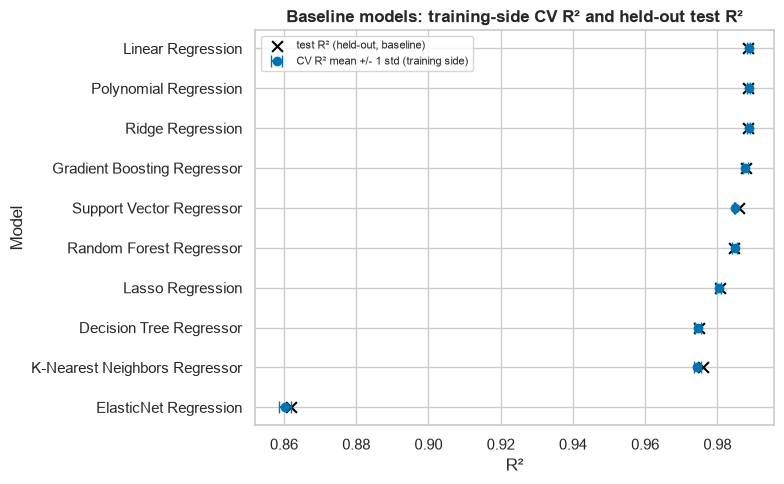

In [70]:
ranks = pd.DataFrame({
    "CV R² (mean) — TRAINING SIDE": cv_table["CV R² (mean)"],
    "CV rank": cv_table["CV rank"],
    "Test R² (baseline) — HELD-OUT": comparison["R²"],
    "Test rank": comparison["Rank (by R²)"],
}).sort_values("CV rank")
display(ranks.round(6))

fig, ax = plt.subplots(figsize=(8, 5))
order = cv_table.index[::-1]
ax.errorbar(cv_table.loc[order, "CV R² (mean)"], range(len(order)), xerr=cv_table.loc[order, "CV R² (std)"],
            fmt="o", capsize=4, label="CV R² mean +/- 1 std (training side)")
ax.scatter(comparison.loc[order, "R²"], range(len(order)), marker="x", s=60, color="black", label="test R² (held-out, baseline)")
ax.set_yticks(range(len(order)))
ax.set_yticklabels(order)
ax.set_title("Baseline models: training-side CV R² and held-out test R²")
ax.set_xlabel("R²")
ax.set_ylabel("Model")
ax.legend(fontsize=8)
finalize(fig, "regression_cv_vs_test_r2")
plt.show()

### Technical Result
*Generated from the computation above; it updates automatically when the notebook is re-run.*

In [71]:
same_order = list(cv_table.index) == list(comparison.index)
display(Markdown("\n".join([
    f"- Highest mean CV R²: {cv_table.index[0]} ({cv_table['CV R² (mean)'].iloc[0]:.6f}); "
    f"lowest: {cv_table.index[-1]} ({cv_table['CV R² (mean)'].iloc[-1]:.6f}).",
    "- Models whose mean CV R² equals the highest to 6 decimals: "
    + ", ".join(cv_table.index[(cv_table["CV R² (mean)"] - cv_table["CV R² (mean)"].iloc[0]).abs() < 5e-7]) + ".",
    f"- Largest CV standard deviation: {cv_table['CV R² (std)'].max():.5f} ({cv_table['CV R² (std)'].idxmax()}); "
    f"smallest: {cv_table['CV R² (std)'].min():.5f} ({cv_table['CV R² (std)'].idxmin()}).",
    f"- CV ranking identical to the test ranking: {'yes' if same_order else 'no'}.",
])))

- Highest mean CV R²: Linear Regression (0.988676); lowest: ElasticNet Regression (0.860214).
- Models whose mean CV R² equals the highest to 6 decimals: Linear Regression, Polynomial Regression, Ridge Regression.
- Largest CV standard deviation: 0.00161 (ElasticNet Regression); smallest: 0.00006 (Support Vector Regressor).
- CV ranking identical to the test ranking: no.

> ### ✍️ TEAM ANALYSIS REQUIRED — `REG-CV`: Cross-validation results
> **Author:** _(write your name)_
>
> Interpret the output above in your own words (course guideline 7.5: no AI-written analysis).
>
> - Does training-side CV support the held-out test ranking from 20.11? Where do they differ?
> - How large are the fold-to-fold standard deviations compared with the differences between the top models?
> - Which models generalize differently (large train-vs-CV or CV-vs-test gaps)?
>
> *When done, replace this whole cell with your answer under the heading `### Team analysis — REG-CV`.*

## 21.2 Nominating the two models for formal tuning

**Rule (fixed before looking at any tuning result):** nominate the **two models with the highest mean
CV R²** (21.1) that still have hyperparameters to tune. Two cases are not eligible:

* **Linear Regression** — ordinary least squares has no hyperparameters.
* A model whose baseline is **the same fitted function** as a higher-ranked model — detected by
  identical *training-set* predictions (the test set is not used for this check). Polynomial Regression
  is the case to watch: its only hyperparameter, the degree, was already chosen by cross-validation in
  20.5; if degree 1 was chosen it reproduces Linear Regression exactly.

**Search spaces** are defined here for **every** tunable model *before* the nomination is computed, so
that the grid cannot be tailored to whichever models are nominated. Each model's baseline setting is
inside its own grid, so a tuned model can never be *worse on CV* than its baseline.

In [72]:
SEARCH_SPACES = {
    "Ridge Regression":              {"model__alpha": list(np.logspace(-3, 3, 25))},
    "Lasso Regression":              {"model__alpha": list(np.logspace(-4, 1, 26))},
    "ElasticNet Regression":         {"model__alpha": list(np.logspace(-4, 0, 9)),
                                      "model__l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9, 1.0]},
    "Polynomial Regression":         {"model__poly__degree": [1, 2, 3],
                                      "model__poly__interaction_only": [False, True]},
    "Decision Tree Regressor":       {"model__max_depth": [3, 5, 7, 8, 9, 10, 12, 15, None],
                                      "model__min_samples_leaf": [1, 5, 10, 20, 40]},
    "Random Forest Regressor":       {"model__n_estimators": [100, 200, 400],
                                      "model__max_depth": [None, 10, 15],
                                      "model__min_samples_leaf": [1, 3, 5, 10]},
    "Gradient Boosting Regressor":   {"model__learning_rate": [0.03, 0.05, 0.1, 0.2],
                                      "model__n_estimators": [100, 200, 400],
                                      "model__max_depth": [2, 3, 4],
                                      "model__subsample": [0.8, 1.0]},
    "Support Vector Regressor":      {"model__kernel": ["linear", "rbf"],
                                      "model__C": [0.3, 1.0, 3.0, 10.0, 30.0],
                                      "model__gamma": ["scale", 0.01, 0.03, 0.1]},
    "K-Nearest Neighbors Regressor": {"model__n_neighbors": [3, 5, 7, 10, 15, 20, 30],
                                      "model__weights": ["uniform", "distance"],
                                      "model__p": [1, 2]},
}

# Eligibility, in CV order
train_preds = {name: fitted[name].predict(X_train) for name in cv_table.index}   # TRAINING predictions only
eligibility = []
for pos, name in enumerate(cv_table.index):
    reason = "eligible"
    if name not in SEARCH_SPACES:
        reason = "no hyperparameters to tune"
    else:
        for higher in cv_table.index[:pos]:
            if np.allclose(train_preds[name], train_preds[higher], rtol=0, atol=1e-8):
                reason = f"same fitted function as {higher} (identical training predictions)"
                break
    eligibility.append({"Model": name, "CV R² (mean)": cv_table.loc[name, "CV R² (mean)"],
                        "Tunable": name in SEARCH_SPACES, "Status": reason})
eligibility = pd.DataFrame(eligibility).set_index("Model")
NOMINEES = list(eligibility.index[eligibility["Status"] == "eligible"][:2])
eligibility["Nominated"] = eligibility.index.isin(NOMINEES)
display(eligibility.round(6))
print("Nominated for formal tuning:", NOMINEES)

,CV R² (mean),Tunable,Status,Nominated
Model,,,,
Linear Regression,0.988676,False,no hyperparameters to tune,False
Polynomial Regression,0.988676,True,same fitted function as Linear Regression (ide...,False
Ridge Regression,0.988676,True,eligible,True
Gradient Boosting Regressor,0.987729,True,eligible,True
Support Vector Regressor,0.984908,True,eligible,False
Random Forest Regressor,0.984856,True,eligible,False
Lasso Regression,0.980358,True,eligible,False
Decision Tree Regressor,0.974555,True,eligible,False
K-Nearest Neighbors Regressor,0.974377,True,eligible,False


Nominated for formal tuning: ['Ridge Regression', 'Gradient Boosting Regressor']


### Technical Result
*Generated from the computation above; it updates automatically when the notebook is re-run.*

In [73]:
display(Markdown("\n".join(
    [f"- Nominee {k}: {n} (mean CV R² {cv_table.loc[n, 'CV R² (mean)']:.6f}, CV rank {cv_table.loc[n, 'CV rank']})."
     for k, n in enumerate(NOMINEES, 1)]
    + [f"- Not eligible: {n} — {s}." for n, s in eligibility["Status"].items() if s != "eligible"]
    + [f"- Search-space sizes: " + ", ".join(
        f"{n} = {int(np.prod([len(v) for v in SEARCH_SPACES[n].values()]))} combinations" for n in NOMINEES) + "."]
)))

- Nominee 1: Ridge Regression (mean CV R² 0.988676, CV rank 3).
- Nominee 2: Gradient Boosting Regressor (mean CV R² 0.987729, CV rank 4).
- Not eligible: Linear Regression — no hyperparameters to tune.
- Not eligible: Polynomial Regression — same fitted function as Linear Regression (identical training predictions).
- Search-space sizes: Ridge Regression = 25 combinations, Gradient Boosting Regressor = 72 combinations.

## 21.3 Formal hyperparameter tuning with GridSearchCV  *(rubric C3)*

**What:** an exhaustive grid search over each nominee's search space. Every candidate setting is scored
by **5-fold cross-validation on the training set** (same `CV` splitter); the best setting is then refitted
on the whole training set (`refit=True`) and evaluated **once** on the held-out test set.

**Why this order:** hyperparameters are chosen only from training-side CV scores, so the test set stays
an honest estimate of performance on unseen data. Using the test set to pick hyperparameters would make
the reported test score optimistic.

**Concept — GridSearchCV:** for *k* candidate settings and 5 folds it fits 5·*k* pipelines, averages
each candidate's fold scores and keeps the best (`best_params_`, `best_score_`).

In [74]:
searches, tuned_results = {}, {}
for name in NOMINEES:
    search = GridSearchCV(build_regression_pipeline(clone(fitted[name].named_steps["model"])),
                          SEARCH_SPACES[name], cv=CV, scoring="r2", n_jobs=-1, refit=True)
    t0 = time.perf_counter()
    search.fit(X_train, y_train)                    # candidates scored by 5-fold CV on TRAINING data only
    search_seconds = time.perf_counter() - t0
    searches[name] = search

    tuned_pred = search.best_estimator_.predict(X_test)      # the ONE evaluation of the tuned model on the test set
    tuned_results[name] = {**regression_metrics(y_test, tuned_pred),
                           "Train R2": r2_score(y_train, search.best_estimator_.predict(X_train)),
                           "search time (s)": round(search_seconds, 1)}
    pd.DataFrame(search.cv_results_).to_csv(
        config.TUNING_DIR / f"regression_{name.lower().replace(' ', '_').replace('-', '_')}_grid{config.OUTPUT_SUFFIX}.csv", index=False)
    print(f"{name}: {len(search.cv_results_['params'])} candidates x {config.CV_FOLDS} folds "
          f"in {search_seconds:.1f} s; best parameters {search.best_params_}")

Ridge Regression: 25 candidates x 5 folds in 8.7 s; best parameters {'model__alpha': np.float64(0.5623413251903491)}


Gradient Boosting Regressor: 72 candidates x 5 folds in 24.4 s; best parameters {'model__learning_rate': 0.1, 'model__max_depth': 2, 'model__n_estimators': 400, 'model__subsample': 0.8}


**Tuning summary — training side.** Baseline and tuned configuration, the search space, and the
baseline vs. best **cross-validated** R² (both computed with the same 5 training folds, so they are
directly comparable).

In [75]:
def fmt(v):
    return f"{v:.4g}" if isinstance(v, (float, np.floating)) else str(v)

rows = []
for name, search in searches.items():
    best = search.best_index_
    baseline_params = {k: fitted[name].get_params()[k] for k in SEARCH_SPACES[name]}
    rows.append({
        "Model": name,
        "Search space": "; ".join(f"{k.replace('model__', '')}: {[fmt(v) for v in vals]}" for k, vals in SEARCH_SPACES[name].items()),
        "Candidates": len(search.cv_results_["params"]),
        "Baseline configuration": ", ".join(f"{k.replace('model__', '')}={fmt(v)}" for k, v in baseline_params.items()),
        "Tuned configuration (best_params_)": ", ".join(f"{k.replace('model__', '')}={fmt(v)}" for k, v in search.best_params_.items()),
        "Baseline CV R² (mean)": cv_table.loc[name, "CV R² (mean)"],
        "Baseline CV R² (std)": cv_table.loc[name, "CV R² (std)"],
        "Tuned CV R² (mean)": search.best_score_,
        "Tuned CV R² (std)": search.cv_results_["std_test_score"][best],
        "CV R² change": search.best_score_ - cv_table.loc[name, "CV R² (mean)"],
    })
tuning_summary = pd.DataFrame(rows).set_index("Model")
save_table(tuning_summary, "regression_tuning_summary", floatfmt=".6f")
display(tuning_summary.drop(columns="Search space").round(6)
        .assign(**{"CV R² change": tuning_summary["CV R² change"].map("{:+.3e}".format)}))
print("Search spaces:")
for name, space in tuning_summary["Search space"].items():
    print(f"  {name}: {space}")

,Candidates,Baseline configuration,Tuned configuration (best_params_),Baseline CV R² (mean),Baseline CV R² (std),Tuned CV R² (mean),Tuned CV R² (std),CV R² change
Model,,,,,,,,
Ridge Regression,25,alpha=1,alpha=0.5623,0.988676,0.000466,0.988676,0.000466,+7.474e-09
Gradient Boosting Regressor,72,"learning_rate=0.1, n_estimators=100, max_depth...","learning_rate=0.1, max_depth=2, n_estimators=4...",0.987729,0.000652,0.988088,0.000463,+3.590e-04


Search spaces:
  Ridge Regression: alpha: ['0.001', '0.001778', '0.003162', '0.005623', '0.01', '0.01778', '0.03162', '0.05623', '0.1', '0.1778', '0.3162', '0.5623', '1', '1.778', '3.162', '5.623', '10', '17.78', '31.62', '56.23', '100', '177.8', '316.2', '562.3', '1000']
  Gradient Boosting Regressor: learning_rate: ['0.03', '0.05', '0.1', '0.2']; n_estimators: ['100', '200', '400']; max_depth: ['2', '3', '4']; subsample: ['0.8', '1']


**Held-out test set — baseline vs tuned.** Both rows of each pair are **test-set** results on the same
1,975 rows: the baseline from 20.11 and the tuned model evaluated once. The "Improved?" column states the
direction honestly for every metric (for RMSE and MAE, lower is better).

In [76]:
from src.evaluation import before_after_table

ba_rows = []
for name in searches:
    for metric, higher in [("R2", True), ("RMSE", False), ("MAE", False)]:
        ba_rows.append({"model": name, "metric": metric, "before": results[name][metric],
                        "after": tuned_results[name][metric], "higher_is_better": higher})
test_before_after = before_after_table(ba_rows).rename(columns={"model": "Model", "metric": "Metric",
                                                                "Before": "Baseline test", "After": "Tuned test"})
save_table(test_before_after.set_index(["Model", "Metric"]), "regression_tuning_test_before_after", floatfmt=".6f")
# Changes can be very small, so they are shown in scientific notation rather than rounded away.
display(test_before_after.round(6).assign(Change=test_before_after["Change"].map("{:+.3e}".format)))

,Model,Metric,Baseline test,Tuned test,Change,Improved?
0,Ridge Regression,R2,0.988580,0.988579,-4.187e-07,no
1,Ridge Regression,RMSE,2.052404,2.052441,+3.763e-05,no
2,Ridge Regression,MAE,1.641491,1.641532,+4.099e-05,no
3,Gradient Boosting Regressor,R2,0.987958,0.988113,+1.543e-04,yes
4,Gradient Boosting Regressor,RMSE,2.107500,2.093957,-1.354e-02,yes
5,Gradient Boosting Regressor,MAE,1.683939,1.677911,-6.028e-03,yes


### Technical Result
*Generated from the computation above; it updates automatically when the notebook is re-run.*

In [77]:
facts = []
for name, search in searches.items():
    s, t = tuning_summary.loc[name], tuned_results[name]
    facts.append(f"- **{name}** — best parameters: {s['Tuned configuration (best_params_)']} "
                 f"(baseline: {s['Baseline configuration']}).")
    facts.append(f"  - TRAINING-SIDE CV R²: baseline {s['Baseline CV R² (mean)']:.6f} ± {s['Baseline CV R² (std)']:.6f} → "
                 f"tuned {s['Tuned CV R² (mean)']:.6f} ± {s['Tuned CV R² (std)']:.6f} (change {s['CV R² change']:+.2e}).")
    facts.append(f"  - HELD-OUT TEST: R² {results[name]['R2']:.6f} → {t['R2']:.6f} ({t['R2'] - results[name]['R2']:+.2e}); "
                 f"RMSE {results[name]['RMSE']:.4f} → {t['RMSE']:.4f} ({t['RMSE'] - results[name]['RMSE']:+.2e}); "
                 f"MAE {results[name]['MAE']:.4f} → {t['MAE']:.4f} ({t['MAE'] - results[name]['MAE']:+.2e}).")
    mixed = test_before_after[test_before_after["Model"] == name]["Improved?"].nunique() > 1
    if mixed:
        facts.append("  - The test metrics moved in different directions (see the Improved? column).")
display(Markdown("\n".join(facts)))

- **Ridge Regression** — best parameters: alpha=0.5623 (baseline: alpha=1).
  - TRAINING-SIDE CV R²: baseline 0.988676 ± 0.000466 → tuned 0.988676 ± 0.000466 (change +7.47e-09).
  - HELD-OUT TEST: R² 0.988580 → 0.988579 (-4.19e-07); RMSE 2.0524 → 2.0524 (+3.76e-05); MAE 1.6415 → 1.6415 (+4.10e-05).
- **Gradient Boosting Regressor** — best parameters: learning_rate=0.1, max_depth=2, n_estimators=400, subsample=0.8 (baseline: learning_rate=0.1, n_estimators=100, max_depth=3, subsample=1).
  - TRAINING-SIDE CV R²: baseline 0.987729 ± 0.000652 → tuned 0.988088 ± 0.000463 (change +3.59e-04).
  - HELD-OUT TEST: R² 0.987958 → 0.988113 (+1.54e-04); RMSE 2.1075 → 2.0940 (-1.35e-02); MAE 1.6839 → 1.6779 (-6.03e-03).

> ### ✍️ TEAM ANALYSIS REQUIRED — `REG-C3-TUNING`: Hyperparameter tuning
> **Author:** _(write your name)_
>
> Interpret the output above in your own words (course guideline 7.5: no AI-written analysis).
>
> - Did tuning improve generalization? Compare CV with CV and test with test — not across.
> - Was the improvement substantial or marginal, relative to the CV standard deviation?
> - Did each tuned model behave consistently between its CV result and its test result?
> - Did regularization help the linear model? Did the non-linear model capture any additional structure? What trade-offs (accuracy, complexity, training time, interpretability) should the team discuss?
>
> *When done, replace this whole cell with your answer under the heading `### Team analysis — REG-C3-TUNING`.*

## 21.4 Final regression comparison tables

**What:** (1) the mandatory comparison of all ten **baseline** models on the held-out test set, now with
the training-side CV columns alongside (clearly labelled); (2) a **separate** table for the tuned models.
The original baseline table (20.11) is not overwritten.

In [78]:
final_comparison = comparison[["R²", "RMSE", "MAE"]].join(
    pd.DataFrame.from_dict(results, orient="index")[["Train R2", "Fit time (s)"]].rename(columns={"Train R2": "Training R²"})
).join(cv_table[["CV R² (mean)", "CV R² (std)"]].rename(columns={"CV R² (mean)": "CV R² (train-side)", "CV R² (std)": "CV std"}))
final_comparison.insert(0, "Test rank", range(1, len(final_comparison) + 1))
final_comparison.columns = pd.MultiIndex.from_tuples(
    [("", "Test rank"), ("HELD-OUT TEST (baseline)", "R²"), ("HELD-OUT TEST (baseline)", "RMSE"),
     ("HELD-OUT TEST (baseline)", "MAE"), ("TRAINING", "Training R²"), ("TRAINING", "Fit time (s)"),
     ("TRAINING-SIDE 5-FOLD CV", "CV R²"), ("TRAINING-SIDE 5-FOLD CV", "CV std")])
save_table(final_comparison.droplevel(0, axis=1), "regression_final_comparison", floatfmt=".4f")
display(final_comparison.round(4))

tuned_table = pd.DataFrame({
    name: {"Tuned configuration": tuning_summary.loc[name, "Tuned configuration (best_params_)"],
           "Tuned CV R² (train-side)": tuning_summary.loc[name, "Tuned CV R² (mean)"],
           "Tuned test R²": tuned_results[name]["R2"], "Tuned test RMSE": tuned_results[name]["RMSE"],
           "Tuned test MAE": tuned_results[name]["MAE"], "Tuned training R²": tuned_results[name]["Train R2"]}
    for name in searches}).T
tuned_table.index.name = "Model (tuned)"
save_table(tuned_table, "regression_tuned_results", floatfmt=".6f")
display(tuned_table)

HELD-OUT TEST (baseline)                    TRAINING              TRAINING-SIDE 5-FOLD CV        
                              Test rank                       R²    RMSE     MAE Training R² Fit time (s)                   CV R²  CV std
Model                                                                                                                                    
Ridge Regression                      1                   0.9886  2.0524  1.6415      0.9887        0.010                  0.9887  0.0005
Linear Regression                     2                   0.9886  2.0525  1.6416      0.9887        0.010                  0.9887  0.0005
Polynomial Regression                 3                   0.9886  2.0525  1.6416      0.9887        0.013                  0.9887  0.0005
Gradient Boosting Regressor           4                   0.9880  2.1075  1.6839      0.9888        0.263                  0.9877  0.0007
Support Vector Regressor              5                   0.9860  2.2755  1.7953      0.9862        1.208                  0.9849  0.0001
Random Forest Regressor               6                   0.9847  2.3737  1.9153      0.9975        0.885                  0.9849  0.0007
Lasso Regression                      7                   0.9806  2.6760  2.1457      0.9804        0.014                  0.9804  0.0007
K-Nearest Neighbors Regressor         8                   0.9760  2.9736  2.3687      0.9839        0.015                  0.9744  0.0010
Decision Tree Regressor               9                   0.9748  3.0500  2.4536      0.9993        0.025                  0.9746  0.0008
ElasticNet Regression                10                   0.8620  7.1337  5.9257      0.8603        0.013                  0.8602  0.0016

,Tuned configuration,Tuned CV R² (train-side),Tuned test R²,Tuned test RMSE,Tuned test MAE,Tuned training R²
Model (tuned),,,,,,
Ridge Regression,alpha=0.5623,0.988676,0.988579,2.052441,1.641532,0.988705
Gradient Boosting Regressor,"learning_rate=0.1, max_depth=2, n_estimators=4...",0.988088,0.988113,2.093957,1.677911,0.988807


### Technical Result
*Generated from the computation above; it updates automatically when the notebook is re-run.*

In [79]:
flat = final_comparison.droplevel(0, axis=1)
all_test = {**{n: results[n] for n in results}, **{f"{n} (tuned)": tuned_results[n] for n in tuned_results}}
best_r2 = max(all_test, key=lambda n: all_test[n]["R2"])
best_rmse = min(all_test, key=lambda n: all_test[n]["RMSE"])
best_mae = min(all_test, key=lambda n: all_test[n]["MAE"])
display(Markdown("\n".join([
    f"- Among baseline and tuned models on the held-out test set: highest R² = {best_r2} ({all_test[best_r2]['R2']:.6f}); "
    f"lowest RMSE = {best_rmse} ({all_test[best_rmse]['RMSE']:.4f}); lowest MAE = {best_mae} ({all_test[best_mae]['MAE']:.4f}).",
    f"- Highest training-side CV R² (baseline): {flat['CV R²'].idxmax()} ({flat['CV R²'].max():.6f}); "
    + "; ".join(f"tuned {n}: {tuning_summary.loc[n, 'Tuned CV R² (mean)']:.6f}" for n in searches) + ".",
    f"- Largest training-minus-test R² gap (baseline): {(flat['Training R²'] - flat['R²']).idxmax()} "
    f"({(flat['Training R²'] - flat['R²']).max():+.4f}).",
])))

- Among baseline and tuned models on the held-out test set: highest R² = Ridge Regression (0.988580); lowest RMSE = Ridge Regression (2.0524); lowest MAE = Ridge Regression (1.6415).
- Highest training-side CV R² (baseline): Linear Regression (0.988676); tuned Ridge Regression: 0.988676; tuned Gradient Boosting Regressor: 0.988088.
- Largest training-minus-test R² gap (baseline): Decision Tree Regressor (+0.0245).

## 21.5 Diagnostic plots  *(rubric C4)*

**Which model?** The team selects the final model (section 22). The rubric's plots are produced for the
**two tuned nominees** — the finalists of the training-side process — so the team has the diagnostics for
whichever it chooses. The model with the higher **tuned CV R²** is shown first; this ordering is a
mechanical rule, not a selection.

Plots, all on the held-out test set:
* **A. Predicted vs actual** — points on the diagonal are perfect predictions.
* **B. Residual plot + D. residual distribution** — residual = actual − predicted; a well-specified model
  shows residuals scattered evenly around 0 with no pattern.
* **E / C. Coefficients or feature importance** — whichever the model provides (linear coefficients,
  or impurity-based importance for tree ensembles). The Random Forest importance plot in 20.7 is the
  baseline tree-based importance required by the rubric.
* **F. Baseline vs tuned predictions** — how much tuning actually changed individual predictions.

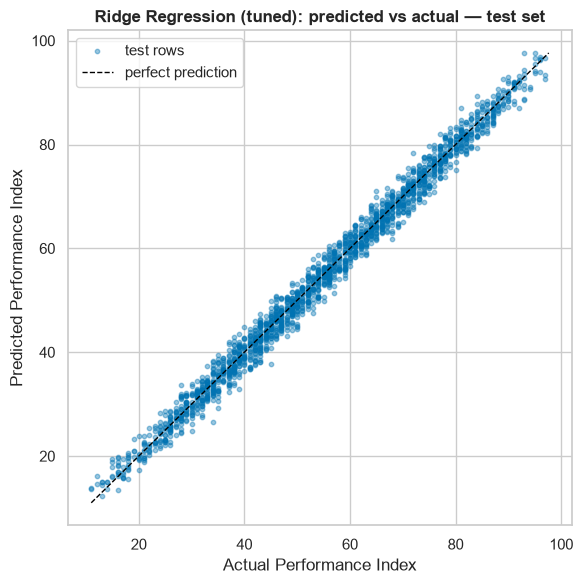

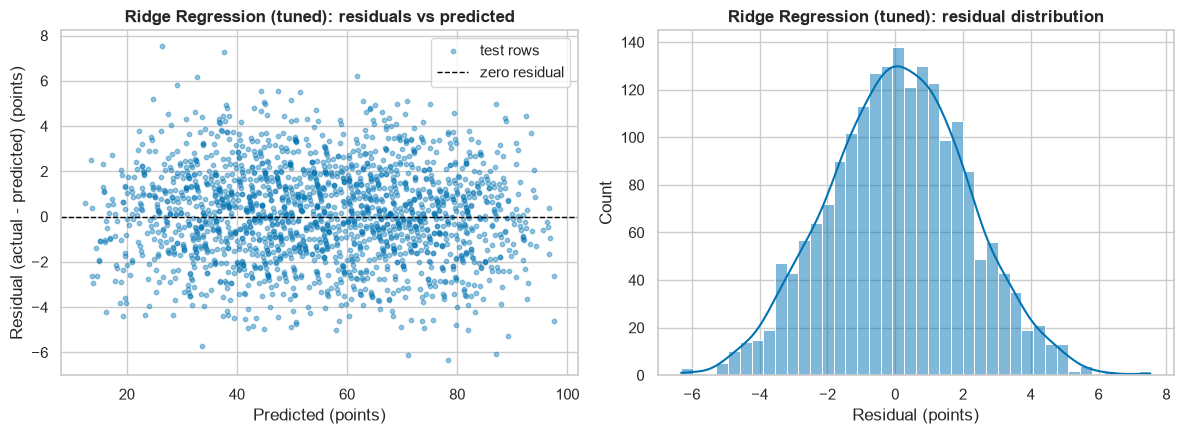

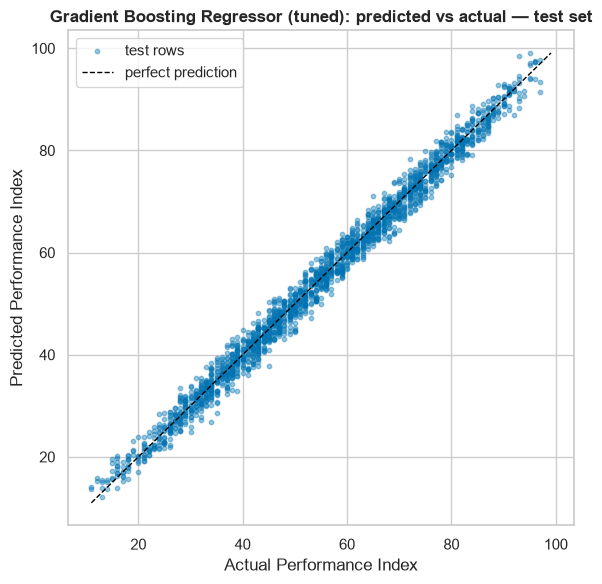

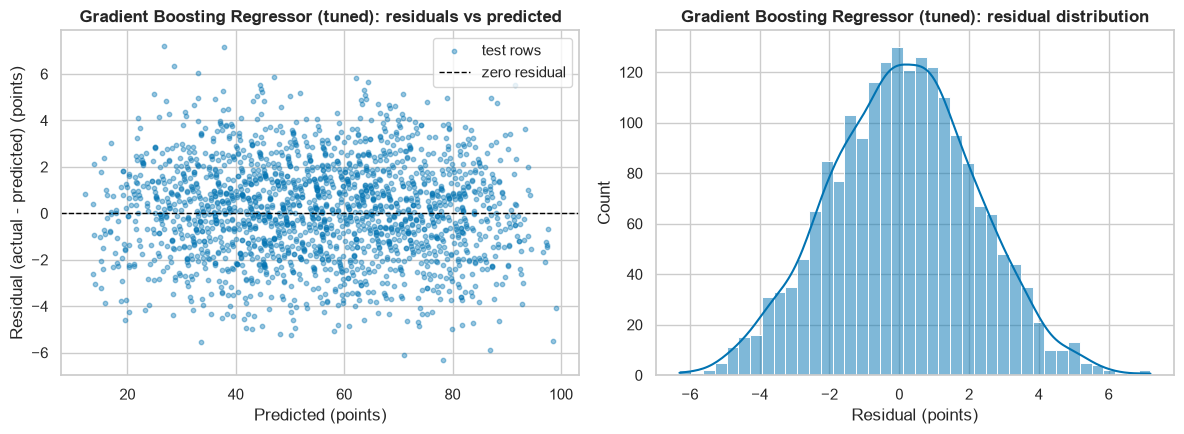

In [80]:
from src.plotting import predicted_vs_actual, residual_plot

DIAGNOSTIC_ORDER = sorted(searches, key=lambda n: searches[n].best_score_, reverse=True)
tuned_models = {name: searches[name].best_estimator_ for name in DIAGNOSTIC_ORDER}
slug = {name: name.lower().replace(" ", "_").replace("-", "_") for name in results}

for name, model in tuned_models.items():
    pred = model.predict(X_test)
    fig = predicted_vs_actual(y_test, pred, f"{name} (tuned): predicted vs actual — test set", units="Performance Index")
    finalize(fig, f"regression_diag_pred_vs_actual_{slug[name]}")
    plt.show()
    fig = residual_plot(y_test, pred, f"{name} (tuned)", units="(points)")
    finalize(fig, f"regression_diag_residuals_{slug[name]}")
    plt.show()

**Coefficients / feature importance of the tuned nominees** (E, C).

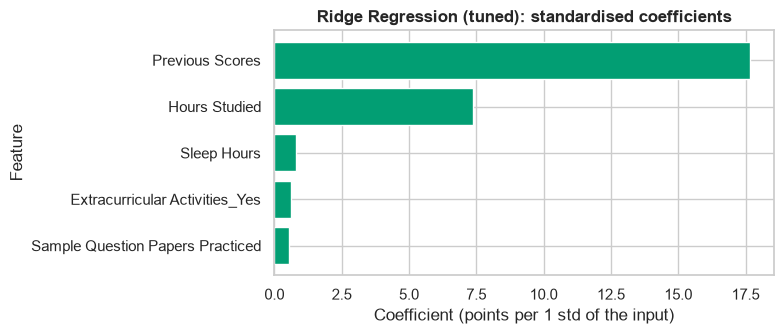

,standardised coefficients
Previous Scores,17.6730
Hours Studied,7.3644
Sleep Hours,0.8159
Extracurricular Activities_Yes,0.6110
Sample Question Papers Practiced,0.5534


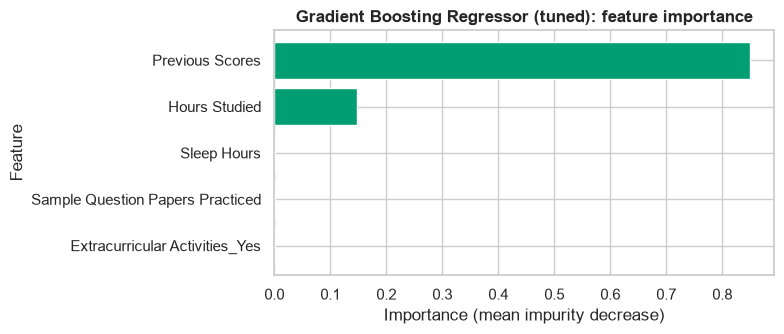

,feature importance
Previous Scores,0.8498
Hours Studied,0.1471
Sleep Hours,0.0019
Sample Question Papers Practiced,0.0010
Extracurricular Activities_Yes,0.0003


In [81]:
for name, model in tuned_models.items():
    est = model.named_steps["model"]
    names = model.named_steps["preprocess"].get_feature_names_out()
    if hasattr(est, "coef_"):
        values, xlabel, what = est.coef_, "Coefficient (points per 1 std of the input)", "standardised coefficients"
    elif hasattr(est, "feature_importances_"):
        values, xlabel, what = est.feature_importances_, "Importance (mean impurity decrease)", "feature importance"
    else:
        print(f"{name}: provides neither coefficients nor impurity-based importances (see 20.7 for Random Forest).")
        continue
    s = pd.Series(values, index=names).sort_values(key=abs, ascending=False)
    fig = feature_importance(s.index, s.values, f"{name} (tuned): {what}", xlabel=xlabel)
    finalize(fig, f"regression_diag_importance_{slug[name]}")
    plt.show()
    display(s.round(4).rename(what).to_frame())

**Baseline vs tuned predictions** (F) — each point is one test row.

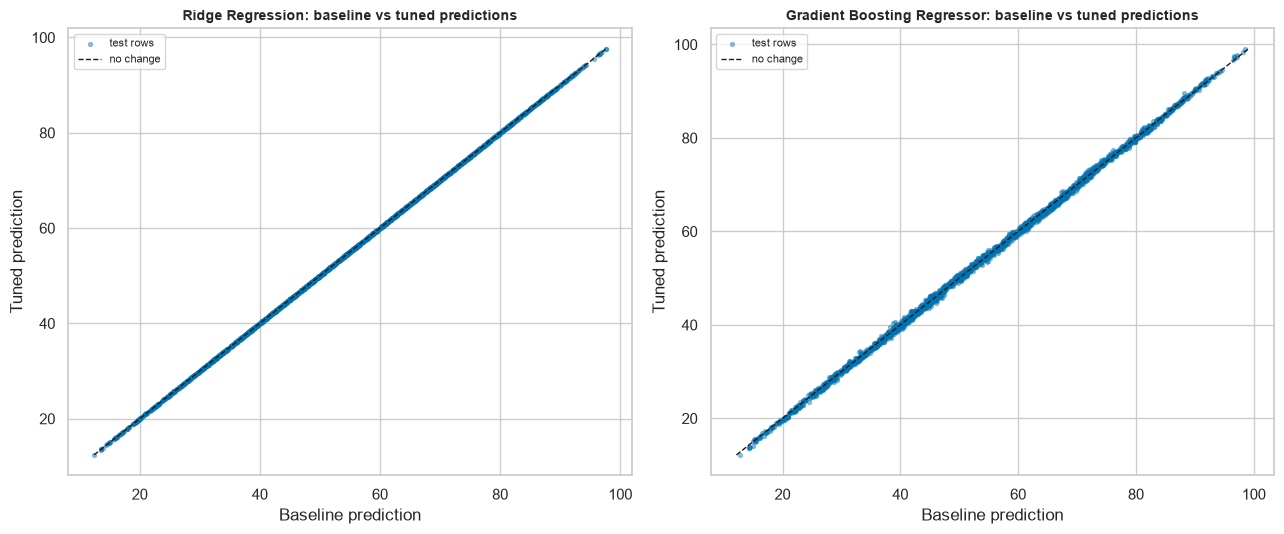

,mean |change|,max |change|,rows changed by > 1 point
Ridge Regression,0.0009,0.0024,0.0
Gradient Boosting Regressor,0.3621,1.4808,50.0


In [82]:
fig, axes = plt.subplots(1, len(tuned_models), figsize=(6.5 * len(tuned_models), 5.5), squeeze=False)
change_stats = {}
for ax, (name, model) in zip(axes[0], tuned_models.items()):
    base_pred, tune_pred = fitted[name].predict(X_test), model.predict(X_test)
    ax.scatter(base_pred, tune_pred, s=8, alpha=0.4, label="test rows")
    lo, hi = min(base_pred.min(), tune_pred.min()), max(base_pred.max(), tune_pred.max())
    ax.plot([lo, hi], [lo, hi], "k--", linewidth=1, label="no change")
    ax.set_title(f"{name}: baseline vs tuned predictions", fontsize=10)
    ax.set_xlabel("Baseline prediction")
    ax.set_ylabel("Tuned prediction")
    ax.legend(fontsize=8)
    diff = np.abs(tune_pred - base_pred)
    change_stats[name] = {"mean |change|": diff.mean(), "max |change|": diff.max(),
                          "rows changed by > 1 point": int((diff > 1).sum())}
finalize(fig, "regression_diag_baseline_vs_tuned")
plt.show()
pd.DataFrame(change_stats).T.round(4)

### Technical Result
*Generated from the computation above; it updates automatically when the notebook is re-run.*

In [83]:
facts = []
for name, model in tuned_models.items():
    res = y_test - model.predict(X_test)
    facts.append(f"- **{name} (tuned)** on the test set: residual mean = {res.mean():+.4f}, residual std = {res.std():.4f}, "
                 f"largest |residual| = {res.abs().max():.3f}; {(res.abs() > 5).sum()} of {len(res):,} rows have |residual| > 5 points.")
    facts.append(f"  - Baseline vs tuned predictions: mean |change| = {change_stats[name]['mean |change|']:.4f}, "
                 f"max |change| = {change_stats[name]['max |change|']:.4f}.")
display(Markdown("\n".join(facts)))

- **Ridge Regression (tuned)** on the test set: residual mean = +0.1003, residual std = 2.0505, largest |residual| = 7.533; 19 of 1,975 rows have |residual| > 5 points.
  - Baseline vs tuned predictions: mean |change| = 0.0009, max |change| = 0.0024.
- **Gradient Boosting Regressor (tuned)** on the test set: residual mean = +0.0991, residual std = 2.0921, largest |residual| = 7.198; 27 of 1,975 rows have |residual| > 5 points.
  - Baseline vs tuned predictions: mean |change| = 0.3621, max |change| = 1.4808.

> ### ✍️ TEAM ANALYSIS REQUIRED — `REG-C4-DIAGNOSTICS`: Diagnostic plots
> **Author:** _(write your name)_
>
> Interpret the output above in your own words (course guideline 7.5: no AI-written analysis).
>
> - Do the residuals look random around zero, or is there a pattern (e.g. at low or high scores)?
> - Do the two finalists make their errors in similar places?
> - What do the coefficients / importances say about which inputs drive the predictions?
>
> *When done, replace this whole cell with your answer under the heading `### Team analysis — REG-C4-DIAGNOSTICS`.*

## 21.6 Saving the fitted pipelines

**What:** every fitted pipeline — the ten baselines and the two tuned models — is saved to `models/`
with compressed `joblib`, together with a manifest recording, for each file, the metrics of **that
exact fitted object** and a fingerprint of the test split.

**Why:** a saved *pipeline* contains its own preprocessing, so it can predict from raw-shaped input
without retraining. The manifest makes each number traceable to the file it describes (a saved model
must never be labelled with the metrics of a different fit), and `scripts/validate_project.py`
independently reloads every file, recomputes its metrics and refits it from scratch to confirm them.

In [84]:
import hashlib
import json
import joblib

config.MODELS_DIR.mkdir(exist_ok=True)
test_fingerprint = hashlib.sha256(",".join(map(str, sorted(X_test.index))).encode()).hexdigest()

to_save = [(name, "baseline", fitted[name]) for name in fitted] + \
          [(name, "tuned", searches[name].best_estimator_) for name in searches]
manifest = []
for name, variant, pipe in to_save:
    path = config.MODELS_DIR / f"regression_{slug[name]}{'_tuned' if variant == 'tuned' else ''}{config.OUTPUT_SUFFIX}.joblib"
    joblib.dump(pipe, path, compress=3)
    reloaded = joblib.load(path)
    assert np.array_equal(reloaded.predict(X_test), pipe.predict(X_test)), f"{path.name}: reload changed predictions"
    manifest.append({"model": name, "variant": variant, "file": path.name,
                     "size_MB": round(path.stat().st_size / 1e6, 3),
                     **{k: float(v) for k, v in regression_metrics(y_test, pipe.predict(X_test)).items()},
                     "params": {k: repr(v) for k, v in pipe.named_steps["model"].get_params().items()}})

manifest_doc = {"track": "regression", "run_mode": config.RUN_MODE, "random_state": config.RANDOM_STATE,
                "n_train": len(X_train), "n_test": len(X_test), "test_index_sha256": test_fingerprint,
                "models": manifest}
(config.MODELS_DIR / f"regression_manifest{config.OUTPUT_SUFFIX}.json").write_text(json.dumps(manifest_doc, indent=2), encoding="utf-8")

saved = pd.DataFrame(manifest).set_index(["model", "variant"])[["file", "size_MB", "R2", "RMSE", "MAE"]]
display(saved.round(4))
print(f"{len(saved)} pipelines saved; total {saved['size_MB'].sum():.1f} MB; largest {saved['size_MB'].max():.1f} MB "
      f"(limit per file {config.MAX_MODEL_FILE_MB} MB). Every file reloaded and reproduced its predictions exactly.")
assert saved["size_MB"].max() <= config.MAX_MODEL_FILE_MB

,,file,size_MB,R2,RMSE,MAE
model,variant,,,,,
Linear Regression,baseline,regression_linear_regression.joblib,0.002,0.9886,2.0525,1.6416
Ridge Regression,baseline,regression_ridge_regression.joblib,0.002,0.9886,2.0524,1.6415
Lasso Regression,baseline,regression_lasso_regression.joblib,0.002,0.9806,2.6760,2.1457
ElasticNet Regression,baseline,regression_elasticnet_regression.joblib,0.002,0.8620,7.1337,5.9257
Polynomial Regression,baseline,regression_polynomial_regression.joblib,0.002,0.9886,2.0525,1.6416
Decision Tree Regressor,baseline,regression_decision_tree_regressor.joblib,0.127,0.9748,3.0500,2.4536
Random Forest Regressor,baseline,regression_random_forest_regressor.joblib,9.426,0.9847,2.3737,1.9153
Gradient Boosting Regressor,baseline,regression_gradient_boosting_regressor.joblib,0.047,0.9880,2.1075,1.6839
Support Vector Regressor,baseline,regression_support_vector_regressor.joblib,0.064,0.9860,2.2755,1.7953


12 pipelines saved; total 9.9 MB; largest 9.4 MB (limit per file 50 MB). Every file reloaded and reproduced its predictions exactly.


### Technical Result
*Generated from the computation above; it updates automatically when the notebook is re-run.*

In [85]:
display(Markdown("\n".join([
    f"- Saved {len(saved)} pipelines ({(saved.index.get_level_values('variant') == 'baseline').sum()} baseline, "
    f"{(saved.index.get_level_values('variant') == 'tuned').sum()} tuned); total size {saved['size_MB'].sum():.1f} MB.",
    "- Each file was reloaded and produced identical test predictions.",
    f"- Test-split fingerprint (SHA-256 of the sorted test row indices): `{test_fingerprint[:16]}…`.",
])))

- Saved 12 pipelines (10 baseline, 2 tuned); total size 9.9 MB.
- Each file was reloaded and produced identical test predictions.
- Test-split fingerprint (SHA-256 of the sorted test row indices): `acb1469812626534…`.

## 22. Model selection and conclusions

This section is written by the team. The facts it should draw on are in 20.11 (baseline test table),
21.1 (training-side CV), 21.3 (tuning), 21.4 (final tables) and 21.5 (diagnostics). No model has been
selected by the notebook.

> ### ✍️ TEAM ANALYSIS REQUIRED — MODEL SELECTION — `REG-MODEL-SELECTION`: Model selection
> **Author:** _(write your name)_
>
> Interpret the output above in your own words (course guideline 7.5: no AI-written analysis).
>
> - Which model should the team select, and why?
> - Are R², RMSE and MAE telling the same story?
> - Does cross-validation support the held-out result?
> - Is there evidence of overfitting in any model?
> - Are the differences between the top models practically meaningful (in Performance Index points)?
> - Does the synthetic nature of the dataset affect how the team should present the result?
>
> *When done, replace this whole cell with your answer under the heading `### Team analysis — REG-MODEL-SELECTION`.*

> ### ✍️ TEAM ANALYSIS REQUIRED — `REG-CONCLUSION`: Conclusions and limitations
> **Author:** _(write your name)_
>
> Interpret the output above in your own words (course guideline 7.5: no AI-written analysis).
>
> - What are the main conclusions of the regression track?
> - What are the limitations of these results, and what would you do differently with real data?
>
> *When done, replace this whole cell with your answer under the heading `### Team analysis — REG-CONCLUSION`.*

## References and AI-assistance disclosure

* 23CSE301 Machine Learning — Capstone Project Guidelines, Algorithm List & Rubrics (2026-27).
* Dataset: N. Narayan, *Student Performance (Multiple Linear Regression)*, Kaggle —
  https://www.kaggle.com/datasets/nikhil7280/student-performance-multiple-linear-regression
* scikit-learn documentation — https://scikit-learn.org/stable/ (`Pipeline`, `ColumnTransformer`,
  `train_test_split`, `StandardScaler`, `OneHotEncoder`, `SimpleImputer`).
* pandas documentation — https://pandas.pydata.org/docs/

**AI assistance (guideline 7.5):** an AI coding assistant generated the code, the supporting `src/`
modules and the factual explanations of methods and concepts. It did **not** write the EDA
observations, the cleaning and feature-engineering justifications, the model-selection reasoning or the
conclusions — those are the ✍️ team cells. Full disclosure: `README.md`.